
# SETUP AND DEPENDENCIES

In [ ]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install xgboost
%pip install lightgbm
%pip install catboost
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

from sklearn.base import clone
from sklearn.model_selection import KFold
import optuna

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import os
import warnings

seed = 1

random.seed(seed)
np.random.seed(seed)
os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["XGBOOST_VERBOSITY"] = "0"
os.environ["PYTHONHASHSEED"] = str(seed)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.ERROR)

sampler=optuna.samplers.TPESampler(seed=seed)

# LOAD DATASET

In [ ]:
import pandas as pd

url = "https://drive.google.com/file/d/1c3JXm-xpe3kNgPxhC2_k-iHhtoWjSqyq/view?usp=sharing"
file_id = url.split('/')[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

local_path = "Phone_Addiction.csv"   # fallback file path

try:
    df = pd.read_csv(download_url)
    print("Loaded from Google Drive")
except Exception as e:
    print("Download failed, loading from local directory")
    df = pd.read_csv(local_path)

display(df.head())

,Unnamed: 0,Name,Age,Gender,Location,Daily_Usage_Hours,Sleep_Hours,Interllectual_Performance,Social_Interactions,Exercise_Hours,...,Apps_Used_Daily,Apps_Used_Weekly,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,ConstantCol,Addiction_Level
0,0,Shannon Francis,13.0,Female,Hansonfort,4.0,"""6.1""",78,5,0.1,...,19,133,3.6,1.7,1.2,Browsing,4,8.7,NaN,10.0
1,1,Scott Rodriguez,17.0,Female,Theodorefort,5.5,"""6.5""",70,5,0.0,...,9,63,1.1,4.0,1.8,Browsing,2,5.3,NaN,10.0
2,2,Adrian Knox,13.0,Other,Lindseystad,5.8,"""5.5""",93,8,0.8,...,8,56,0.3,1.5,0.4,Education,6,5.7,NaN,9.2
3,3,Brittany Hamilton,18.0,Female,West Anthony,3.1,"""3.9""",78,8,1.6,...,7,49,3.1,1.6,0.8,Social Media,8,3.0,NaN,9.8
4,4,Steven Smith,14.0,Other,Port Lindsaystad,2.5,"""6.7""",56,4,1.1,...,20,140,2.6,0.9,1.1,Gaming,10,3.7,NaN,8.6


# PROBLEM AND DATA UNDERSTANDING

## Problem Understanding

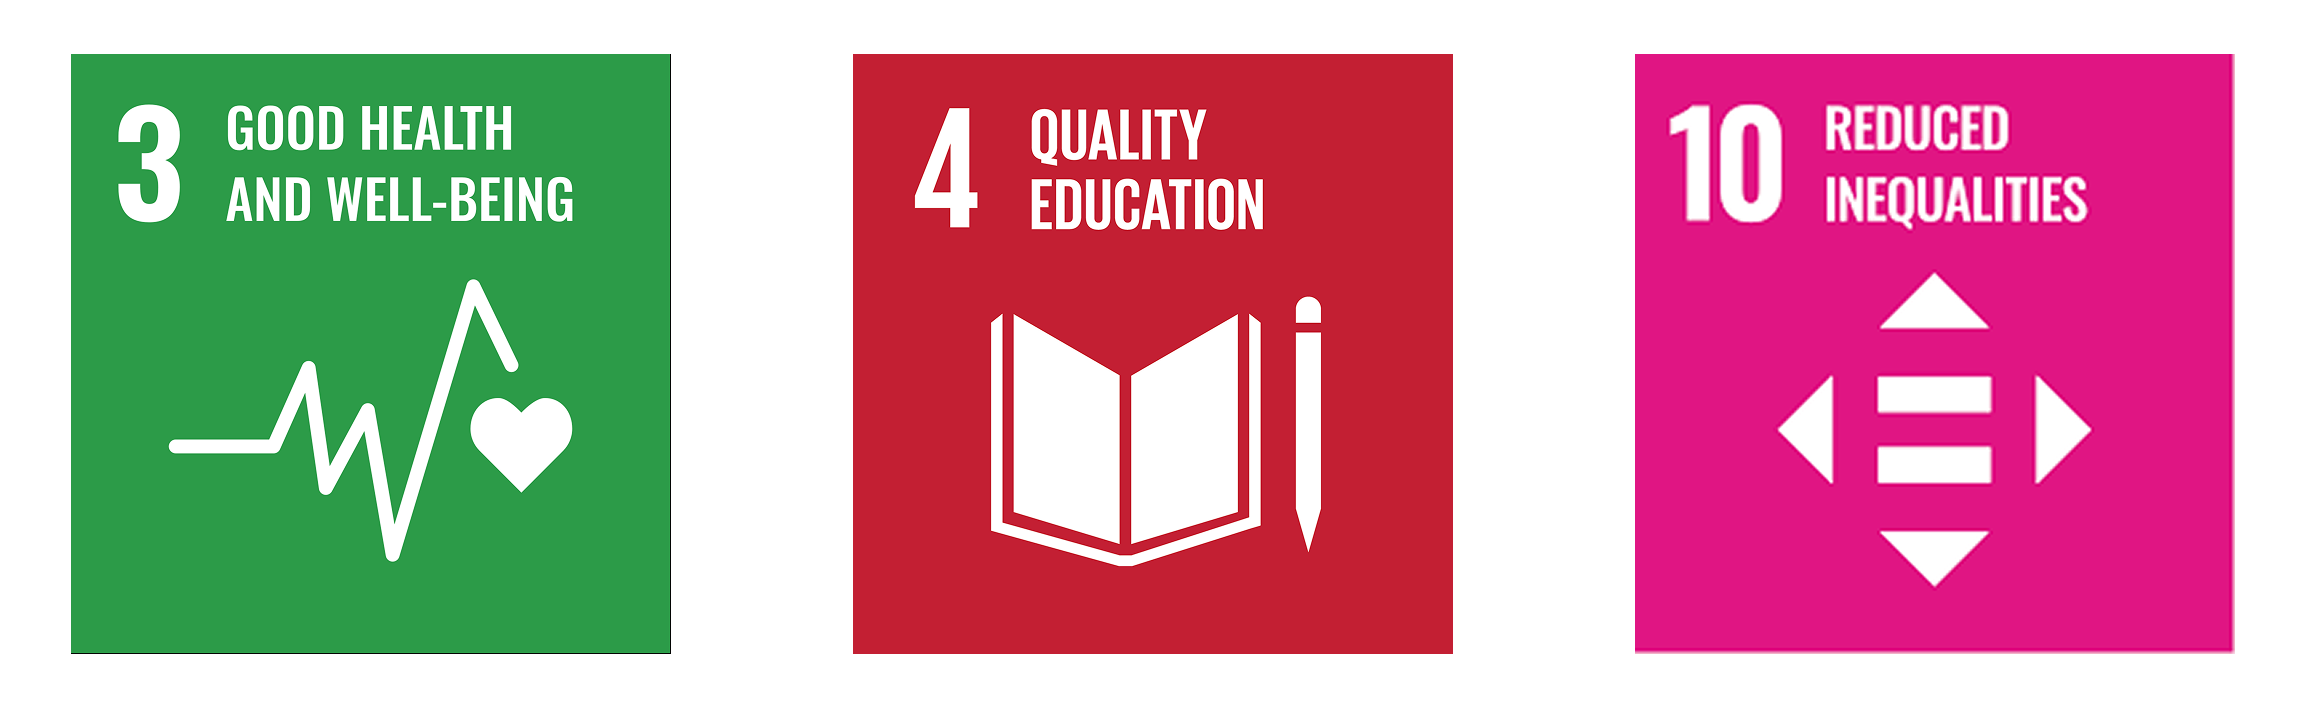


Smartphone addiction is becoming an increasingly significant behavioral concern as mobile devices integrate deeper into daily life. The constant availability of notifications, personalized content, and socially rewarding interactions encourages patterns of use that can gradually shift from convenience to dependency. When this happens, individuals may experience disruptions in sleep, reduced concentration, emotional fluctuations, and diminished real-world social engagement. These outcomes relate directly to SDG 3 (Good Health and Well-Being), which emphasizes mental health, emotional stability, and daily habits that support overall well-being.

Understanding this phenomenon requires careful attention to how digital behavior interacts with emotional states and everyday routines. Prolonged usage, frequent phone-checking, and engagement with various types of applications can be associated with changes in sleep quality, academic focus, productivity, and perceived well-being. These aspects are relevant to SDG 4 (Quality Education), since sustained attention, healthy cognitive functioning, and balanced study habits are important for effective learning. At the same time, indicators related to psychological distress and self-perception can form feedback loops with smartphone use, where certain emotional conditions are both influenced by and reflected in patterns of device engagement.

Differences in these patterns across individuals can suggest that some people are more vulnerable to developing higher levels of dependence than others. By examining how behavioral and psychological profiles relate to addiction levels, it becomes possible to identify groups or profiles that carry a higher risk of problematic use. This contributes to SDG 10 (Reduced Inequalities) in a focused sense, because it supports early recognition of uneven burdens in digital-related strain and helps ensure that preventive efforts and support strategies are directed not only to the average user but also to those who may be more susceptible.

Exploring these interactions helps reveal recurring patterns, contrasting usage profiles, and characteristic tendencies that often accompany higher smartphone addiction levels. Recognizing these signals provides a clearer picture of how problematic use emerges and which factors appear most influential. Such insights support the development of more informed strategies to encourage healthier and more balanced digital habits, in line with the goals of SDG 3, SDG 4, and SDG 10.

## Data Understanding

### Data Structure

In [ ]:
df.shape

(6181, 25)

In [ ]:
df.head()

,Unnamed: 0,Name,Age,Gender,Location,Daily_Usage_Hours,Sleep_Hours,Interllectual_Performance,Social_Interactions,Exercise_Hours,...,Apps_Used_Daily,Apps_Used_Weekly,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,ConstantCol,Addiction_Level
0,0,Shannon Francis,13.0,Female,Hansonfort,4.0,"""6.1""",78,5,0.1,...,19,133,3.6,1.7,1.2,Browsing,4,8.7,NaN,10.0
1,1,Scott Rodriguez,17.0,Female,Theodorefort,5.5,"""6.5""",70,5,0.0,...,9,63,1.1,4.0,1.8,Browsing,2,5.3,NaN,10.0
2,2,Adrian Knox,13.0,Other,Lindseystad,5.8,"""5.5""",93,8,0.8,...,8,56,0.3,1.5,0.4,Education,6,5.7,NaN,9.2
3,3,Brittany Hamilton,18.0,Female,West Anthony,3.1,"""3.9""",78,8,1.6,...,7,49,3.1,1.6,0.8,Social Media,8,3.0,NaN,9.8
4,4,Steven Smith,14.0,Other,Port Lindsaystad,2.5,"""6.7""",56,4,1.1,...,20,140,2.6,0.9,1.1,Gaming,10,3.7,NaN,8.6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6181 entries, 0 to 6180
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 6181 non-null   int64  
 1   Name                       5873 non-null   object 
 2   Age                        5756 non-null   float64
 3   Gender                     6062 non-null   object 
 4   Location                   6000 non-null   object 
 5   Daily_Usage_Hours          5788 non-null   float64
 6   Sleep_Hours                6181 non-null   object 
 7   Interllectual_Performance  6181 non-null   int64  
 8   Social_Interactions        6181 non-null   int64  
 9   Exercise_Hours             6181 non-null   float64
 10  Anxiety_Level              6181 non-null   int64  
 11  Depression_Level           6181 non-null   int64  
 12  Self_Esteem                6181 non-null   int64  
 13  Screen_Time_Before_Bed     6181 non-null   float

### Statistical Summary

#### Numerical

In [ ]:
df.describe()

NameError: name 'df' is not defined

#### Categorical

In [ ]:
df.describe(include=['object'])

,Name,Gender,Location,Sleep_Hours,Phone_Usage_Purpose
count,5873,6062,6000,6181,6181
unique,2931,6,2718,71,6
top,David Williams,Female,Unknown,"""6.1""",Gaming
freq,6,2383,185,191,1795


### Missing Value

In [ ]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing Pct': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Pct', ascending=False))

                   Missing Count  Missing Pct
ConstantCol                 6181   100.000000
Age                          425     6.875910
Daily_Usage_Hours            393     6.358194
Name                         308     4.983012
Location                     181     2.928329
Gender                       119     1.925255


### Distributions

In [ ]:
cat_col = df.select_dtypes(exclude=["number"]).columns
cat_col

Index(['Name', 'Gender', 'Location', 'Sleep_Hours', 'Phone_Usage_Purpose'], dtype='object')

In [ ]:
num_col = df.select_dtypes(include=["int64", "float64"]).columns
num_col

Index(['Unnamed: 0', 'Age', 'Daily_Usage_Hours', 'Interllectual_Performance',
       'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level',
       'Depression_Level', 'Self_Esteem', 'Screen_Time_Before_Bed',
       'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Apps_Used_Weekly',
       'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
       'Family_Communication', 'Weekend_Usage_Hours', 'ConstantCol',
       'Addiction_Level'],
      dtype='object')

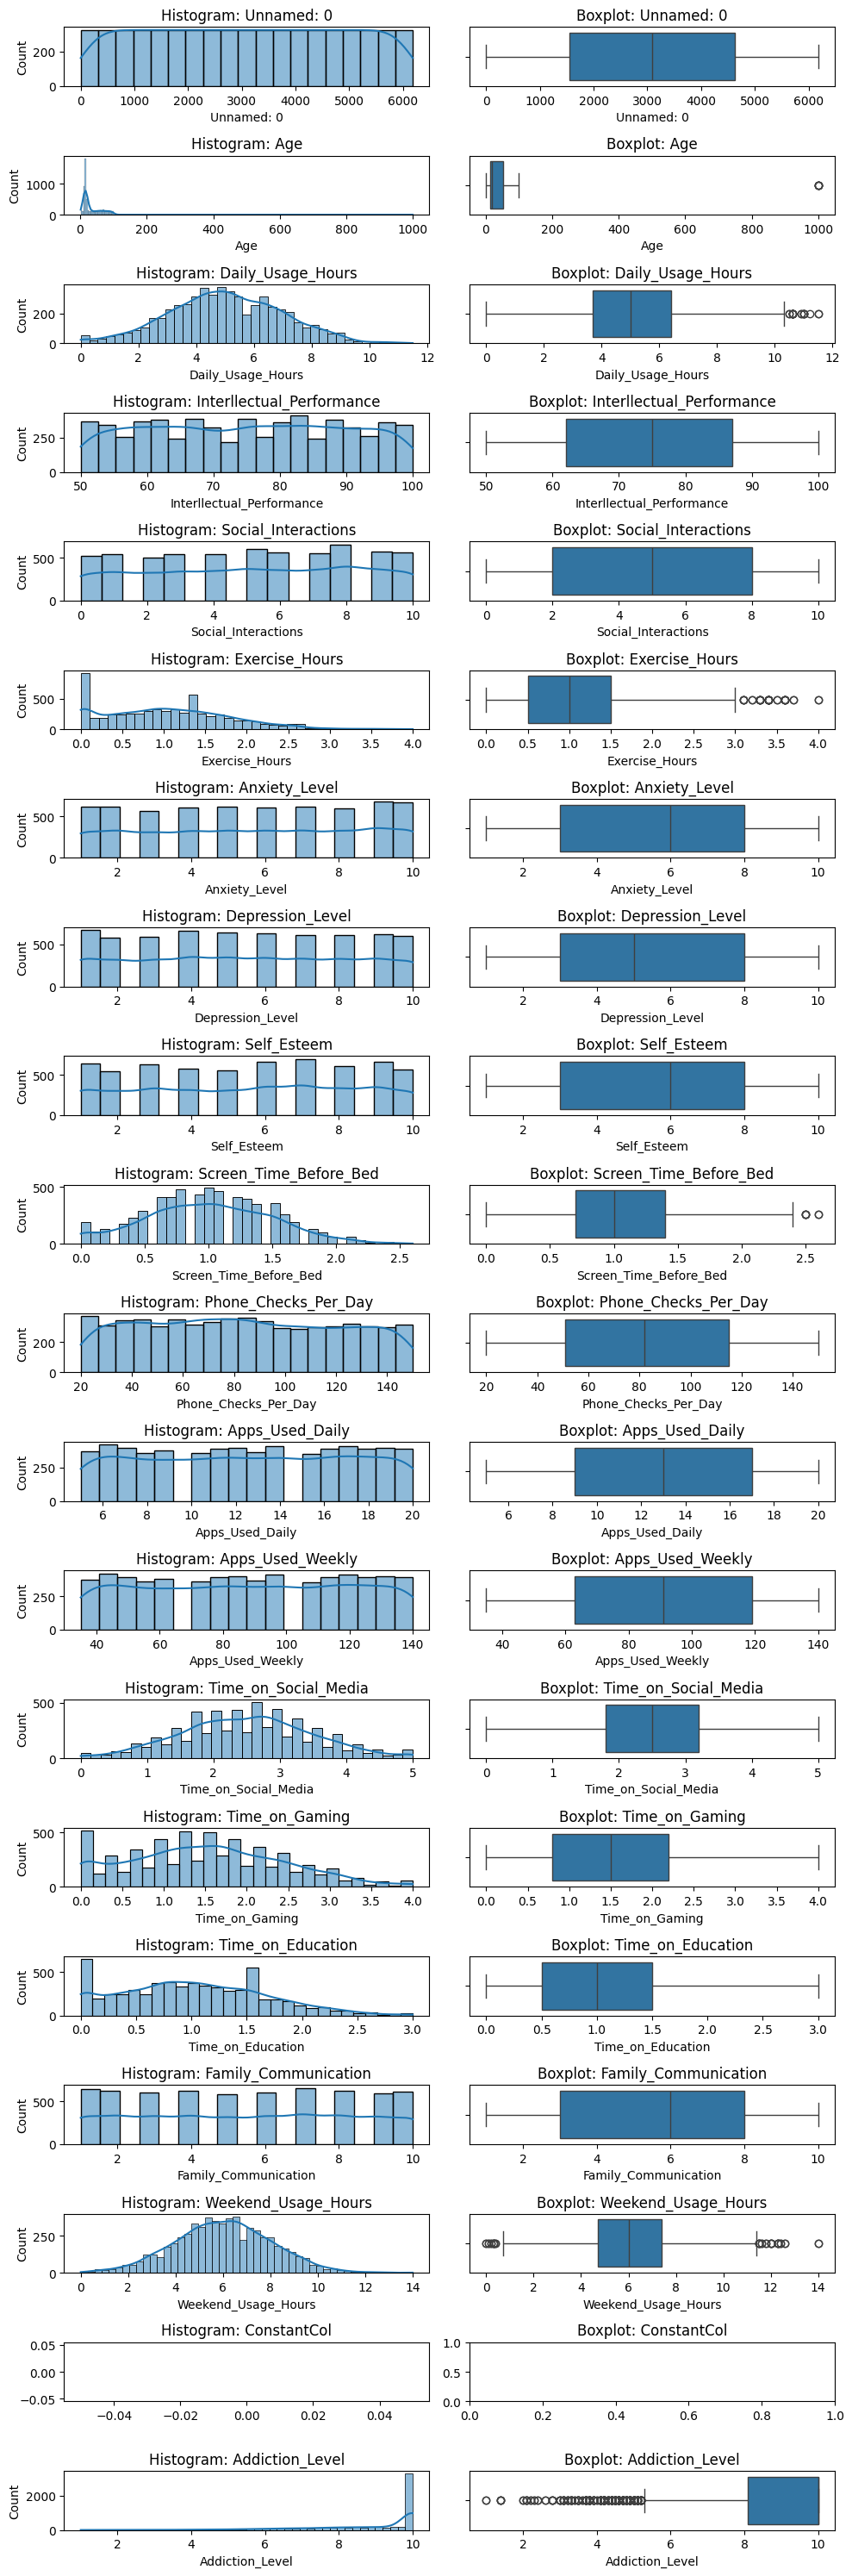

In [ ]:
for col in num_col:
    df[col] = pd.to_numeric(df[col], errors="coerce")

n = len(num_col)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(10, 1.5*n))

for i, col in enumerate(num_col):

    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Histogram: {col}")

    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

`ConstantCol` and `Unnamed: 0` are uninformative, `Age` distribution is skewed due to the outlier, that is the unsensible value 999. These will be handled in preprocessing step. The other feature is normal though having outlier which will be explored more how minor the outliers are in the preprocessing step.

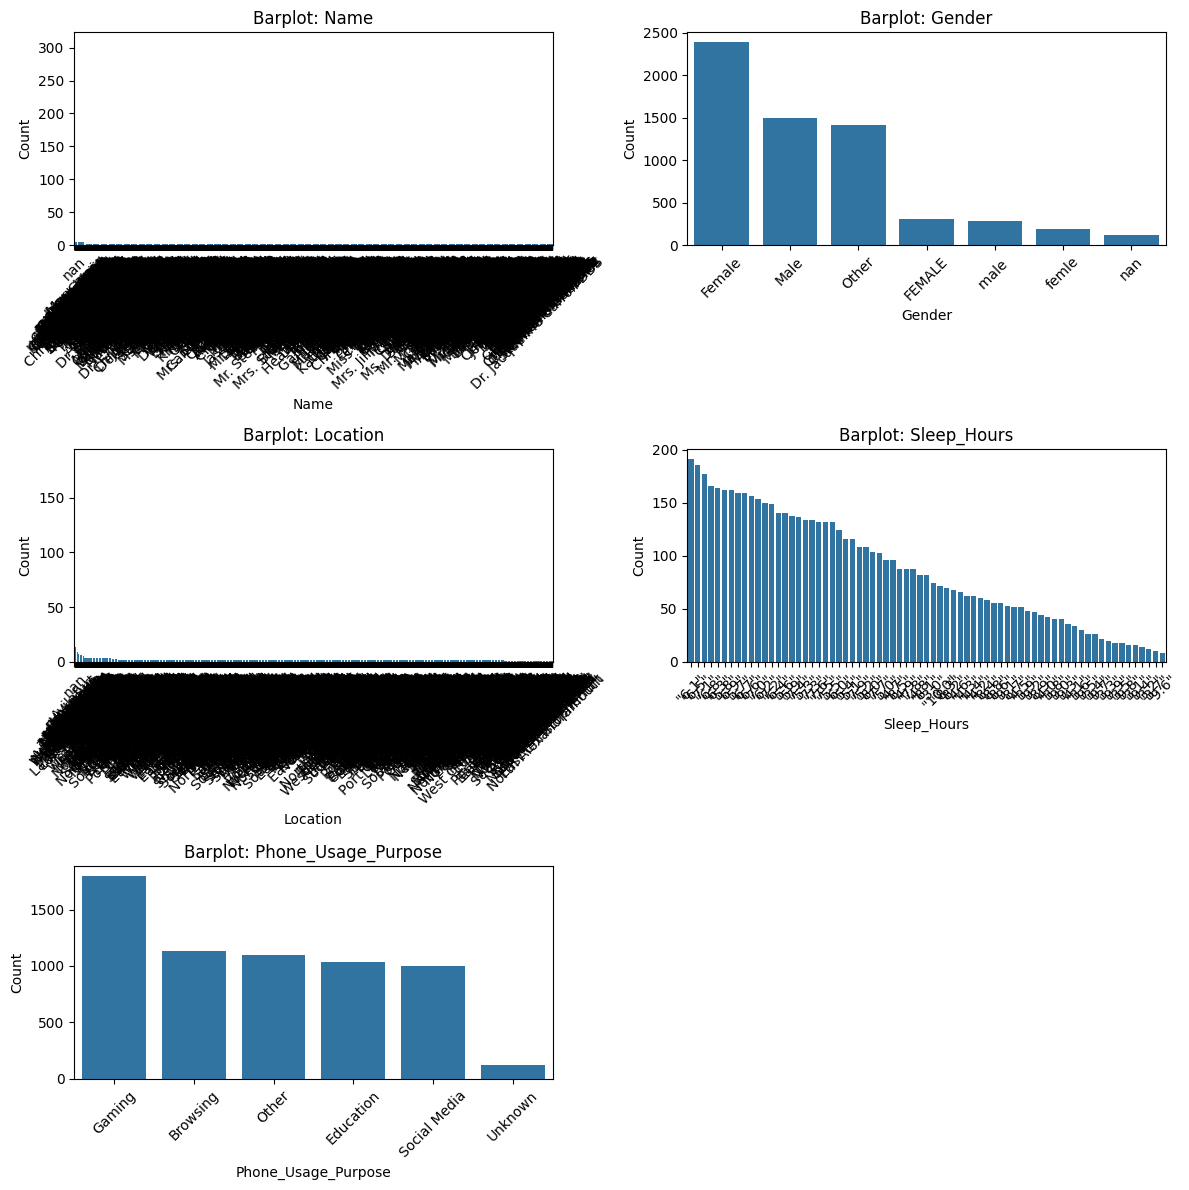

In [ ]:
n = len(cat_col)

cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))

axes = np.array(axes).reshape(rows, cols)

idx = 0
for r in range(rows):
    for c in range(cols):
        if idx < n:
            col = cat_col[idx]
            value_counts = df[col].value_counts(dropna=False)

            sns.barplot(
                x=value_counts.index.astype(str),
                y=value_counts.values,
                ax=axes[r, c]
            )

            axes[r, c].set_title(f"Barplot: {col}")
            axes[r, c].set_xlabel(col)
            axes[r, c].set_ylabel("Count")
            axes[r, c].tick_params(axis='x', rotation=45)

        else:
            # Hide empty subplot
            axes[r, c].axis("off")

        idx += 1

plt.tight_layout()
plt.show()

`Name` and `Location` are uninformative. Meanwhile, `Sleep_Hours` seems to be numerical value but the type mismatched due to additional " as the prefix and suffix.

### Correlation

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

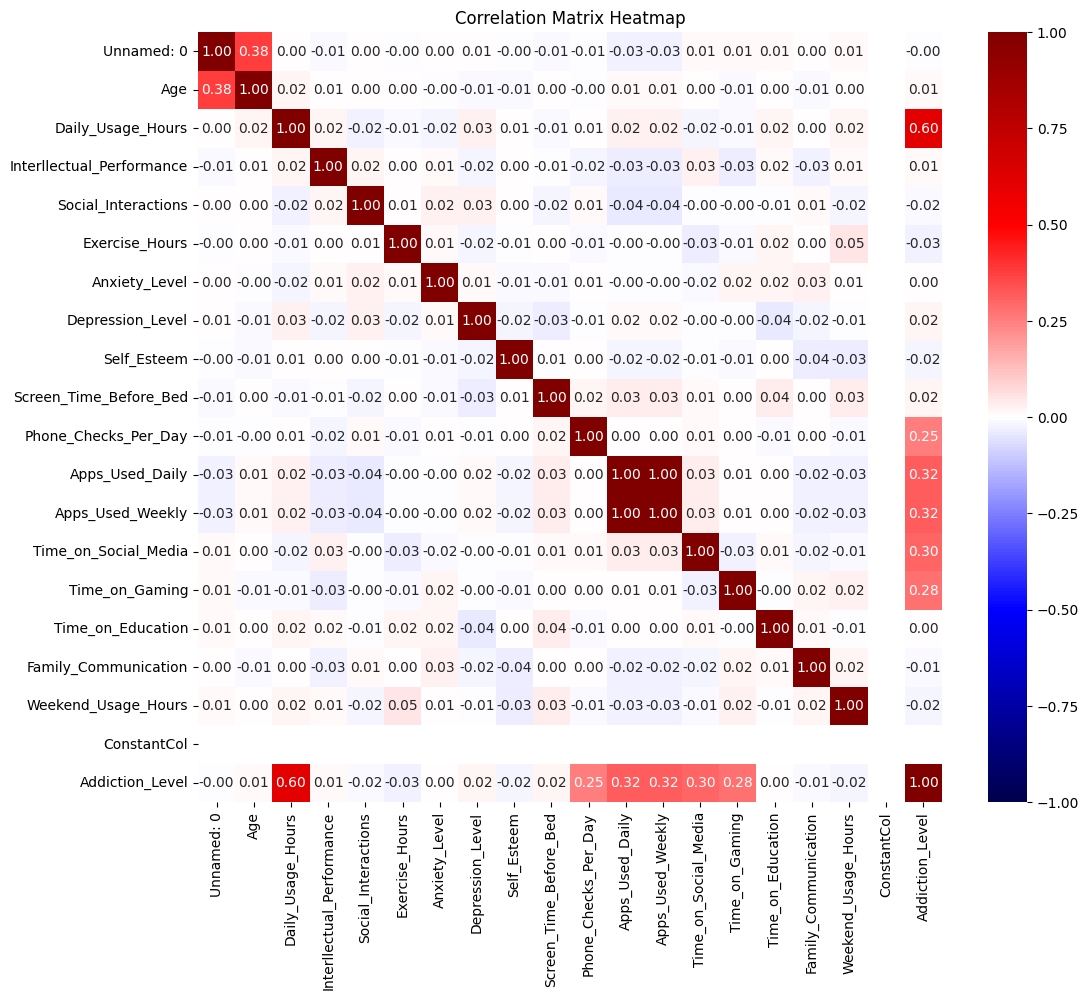

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
corr = numeric_df.corr()
sns.heatmap(corr,
            annot=True,
            cmap='seismic',
            fmt=".2f",
            vmin=-1,
            vmax=1)
plt.title('Correlation Matrix Heatmap')

The correlation matrix indicates that most variables have very weak linear relationships, clustering close to zero. A few digital-behavior features, such as `Daily_Usage_Hours`, `Time_on_Gaming`, `Phone_Checks_Per_Day`, `Apps_Used_Daily`, `Apps_Used_Weekly`, and `Time_on_Social_Media`, show small positive correlations with `Addiction_Level`, meaning heavier phone engagement tends to align with slightly higher addiction scores. `Daily_Usage_Hours` is the only variable with a moderately stronger link to addiction. Psychological and lifestyle features contribute almost no linear signal, suggesting that any meaningful patterns in this dataset likely arise from non-linear relationships rather than simple pairwise correlations. But it should be noted that any correlation does not translates to causation.

In addition we see that `Apps_Used_Daily` and `Apps_Used_Weekly` has perfect positive correlation which by intuition and as stated in the dataset description is basically the same variable in different unit. This will be handled in the preprocessing step.

# DATA PREPROCESSING

## Dropping unpredictive and meaningless feature

In [ ]:
meaningless_suspect = ["Name", "Location", "Unnamed: 0", "ConstantCol"]

print(f"Number of rows: {len(df)}")
for col in meaningless_suspect:
    print(f"Number of unique value in column {col}: {df[col].nunique()}")

Number of rows: 6181
Number of unique value in column Name: 2931
Number of unique value in column Location: 2718
Number of unique value in column Unnamed: 0: 6181
Number of unique value in column ConstantCol: 0


In [ ]:
for col in meaningless_suspect:
    print(df[col].value_counts())

Name
David Williams     6
Richard Smith      6
Gregory Johnson    6
Michael Garcia     6
Michael Brown      6
                  ..
Rose Figueroa      1
Travis Owens       1
David Oliver       1
Jessica Berg       1
David White        1
Name: count, Length: 2931, dtype: int64
Location
Unknown                 185
Floresview               16
Mooreburgh               15
New Charles              14
Avilafurt                14
                       ... 
Smithfurt                 1
East Christopherfurt      1
Allenville                1
Robertsonstad             1
Masseyfort                1
Name: count, Length: 2718, dtype: int64
Unnamed: 0
6180    1
0       1
1       1
2       1
3       1
       ..
9       1
8       1
7       1
6       1
5       1
Name: count, Length: 6181, dtype: int64
Series([], Name: count, dtype: int64)


These four columns are meaningless, the constant column are all missing, meanwhile unnamed column is just an ID. Hence, shall be dropped. Names and locations have too much unique value too and does not really have meaningful feature that can be extracted like common last name, honorifics, or bigger common region in location. Hence, these 4 rows are meaningless and should be dropped.

In [ ]:
df = df.drop(columns=meaningless_suspect, axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6181 entries, 0 to 6180
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        5756 non-null   float64
 1   Gender                     6062 non-null   object 
 2   Daily_Usage_Hours          5788 non-null   float64
 3   Sleep_Hours                6181 non-null   object 
 4   Interllectual_Performance  6181 non-null   int64  
 5   Social_Interactions        6181 non-null   int64  
 6   Exercise_Hours             6181 non-null   float64
 7   Anxiety_Level              6181 non-null   int64  
 8   Depression_Level           6181 non-null   int64  
 9   Self_Esteem                6181 non-null   int64  
 10  Screen_Time_Before_Bed     6181 non-null   float64
 11  Phone_Checks_Per_Day       6181 non-null   int64  
 12  Apps_Used_Daily            6181 non-null   int64  
 13  Apps_Used_Weekly           6181 non-null   int64

## Drop duplicated values

In [ ]:
df.duplicated().sum()

np.int64(174)

Duplicated entries are meanigless and should be dropped

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

## Fixing mismatched data types

`Sleep_Hours` is a numeric value is interpreted as object as python due to the unnecessary quotation mark around the number hence shall be cleaned and casted back to numeric.

In [ ]:
df["Sleep_Hours"] = df["Sleep_Hours"].astype(str).str.strip('"').astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6007 entries, 0 to 6170
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        5588 non-null   float64
 1   Gender                     5888 non-null   object 
 2   Daily_Usage_Hours          5626 non-null   float64
 3   Sleep_Hours                6007 non-null   float64
 4   Interllectual_Performance  6007 non-null   int64  
 5   Social_Interactions        6007 non-null   int64  
 6   Exercise_Hours             6007 non-null   float64
 7   Anxiety_Level              6007 non-null   int64  
 8   Depression_Level           6007 non-null   int64  
 9   Self_Esteem                6007 non-null   int64  
 10  Screen_Time_Before_Bed     6007 non-null   float64
 11  Phone_Checks_Per_Day       6007 non-null   int64  
 12  Apps_Used_Daily            6007 non-null   int64  
 13  Apps_Used_Weekly           6007 non-null   int64  
 1

## Fixing category inconcistencies and detecting hidden missing value

In [ ]:
cat_col = df.select_dtypes(exclude=["number"]).columns

In [ ]:
for col in cat_col:
    print(df[col].value_counts())

Gender
Female    2298
Male      1437
Other     1386
FEMALE     300
male       284
femle      183
Name: count, dtype: int64
Phone_Usage_Purpose
Gaming          1766
Browsing        1075
Other           1070
Education       1001
Social Media     972
Unknown          123
Name: count, dtype: int64


In [ ]:
df["Gender"] = (
    df["Gender"]
    .str.strip()
    .str.lower()
    .replace("femle", "female")
)

df["Gender"] = df["Gender"].apply(
    lambda x: x.capitalize() if isinstance(x, str) else x
)


In [ ]:
df["Phone_Usage_Purpose"] = df["Phone_Usage_Purpose"].replace("Unknown", np.nan)

Only unknown in `Phone_Usage_Purpose` is converted as missing, the unknown in Location is treated as just another class due to the category being the major category in the features hence assumed as a signal. In addition, from the value counts, name and location has too much unique values, it should be binary encoded.

## Removing duplicated feature

In [ ]:
corr_value = df["Apps_Used_Daily"]\
.corr(df["Apps_Used_Weekly"])
print(corr_value)

1.0


The column `Apps_Used_Weekly` is basically the same column as `Apps_Used_Daily`, just in different units, we shall drop one, and since other feature are mostly in Daily unit, the weekly feature should be dropped.

In [ ]:
df = df.drop(columns=["Apps_Used_Weekly"])

## Handling unsensible values if any

In [ ]:
num_col = df.select_dtypes(include=["number"]).columns

In [ ]:
df[num_col].describe()

,Age,Daily_Usage_Hours,Sleep_Hours,Interllectual_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,5588.000000,5626.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000,6007.000000
mean,34.596278,5.015571,6.487648,74.947894,5.100216,1.040636,5.589812,5.461961,5.548027,1.005810,83.054936,12.607458,2.499201,1.526802,1.015632,5.463959,6.009106,8.883852
std,39.446259,1.955591,1.491030,14.665653,3.137213,0.734735,2.890650,2.870065,2.860152,0.492999,37.713857,4.612569,0.986369,0.934732,0.647259,2.867014,2.017052,1.607977
min,2.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,15.000000,3.700000,5.500000,62.000000,2.000000,0.400000,3.000000,3.000000,3.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.050000
50%,18.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,53.000000,6.375000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.400000,115.000000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,999.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


Age of 999 is unsensible, it will be chekced further through the boxplot.

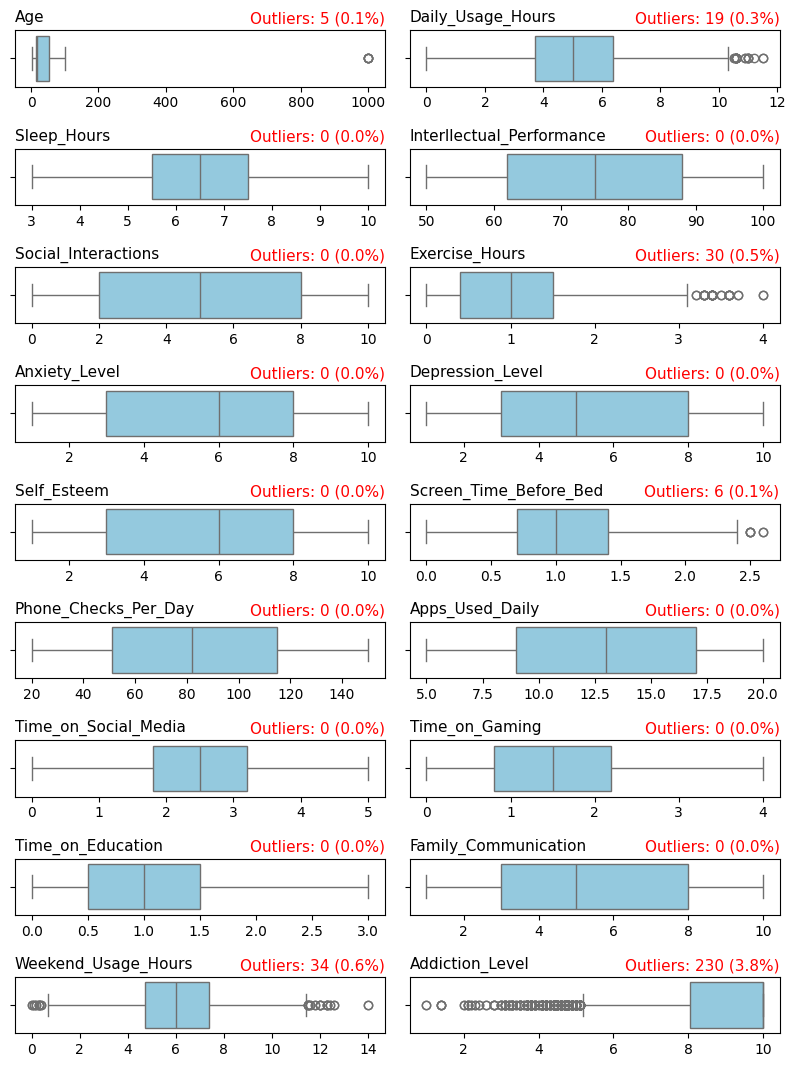

In [ ]:
def count_outliers(x):
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = (x < lower) | (x > upper)
    return np.sum(outliers), np.mean(outliers) * 100

n = len(num_col)
cols = 2
rows = int(np.ceil(n / cols))

plt.figure(figsize=(8, rows * 1.2))

for i, col in enumerate(num_col, 1):
    x = df[col].dropna()
    out_n, out_pct = count_outliers(x)

    plt.subplot(rows, cols, i)
    sns.boxplot(x=x, orient="h", color="skyblue")

    plt.title(f"{col}", fontsize=11, loc="left")
    plt.xlabel("")

    plt.text(1, 1.2,
             f"Outliers: {out_n} ({out_pct:.1f}%)",
             transform=plt.gca().transAxes,
             ha="right", va="center",
             fontsize=11, color="red")

plt.tight_layout()
plt.show()

Largest simple percentage is at most 3.2%, especially it is in the label, in the predictor is at most 0.5% The outlier will just be treated as normal variability of the data. But the age outlier is unsensible and it seems that it is safe if we remove age above 150 from the plot since the upperbound of the plot does not exceed 150.

In [ ]:
cap_value = df.loc[df["Age"] <= 150, "Age"].max()
df.loc[df["Age"] > 150, "Age"] = cap_value

# SPLITTING

In [ ]:
TARGET = "Addiction_Level"
y = df[TARGET]
X = df.drop(columns=[TARGET], axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=284091, stratify=y)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(4805, 19)
(4805,)


In [ ]:
print(X_test.shape)
print(y_test.shape)

(1202, 19)
(1202,)


# FURTHER DATA PREPROCESSING

## Fill missing value

In [ ]:
num_col = X_train.select_dtypes(include=["number"]).columns

### Numeric

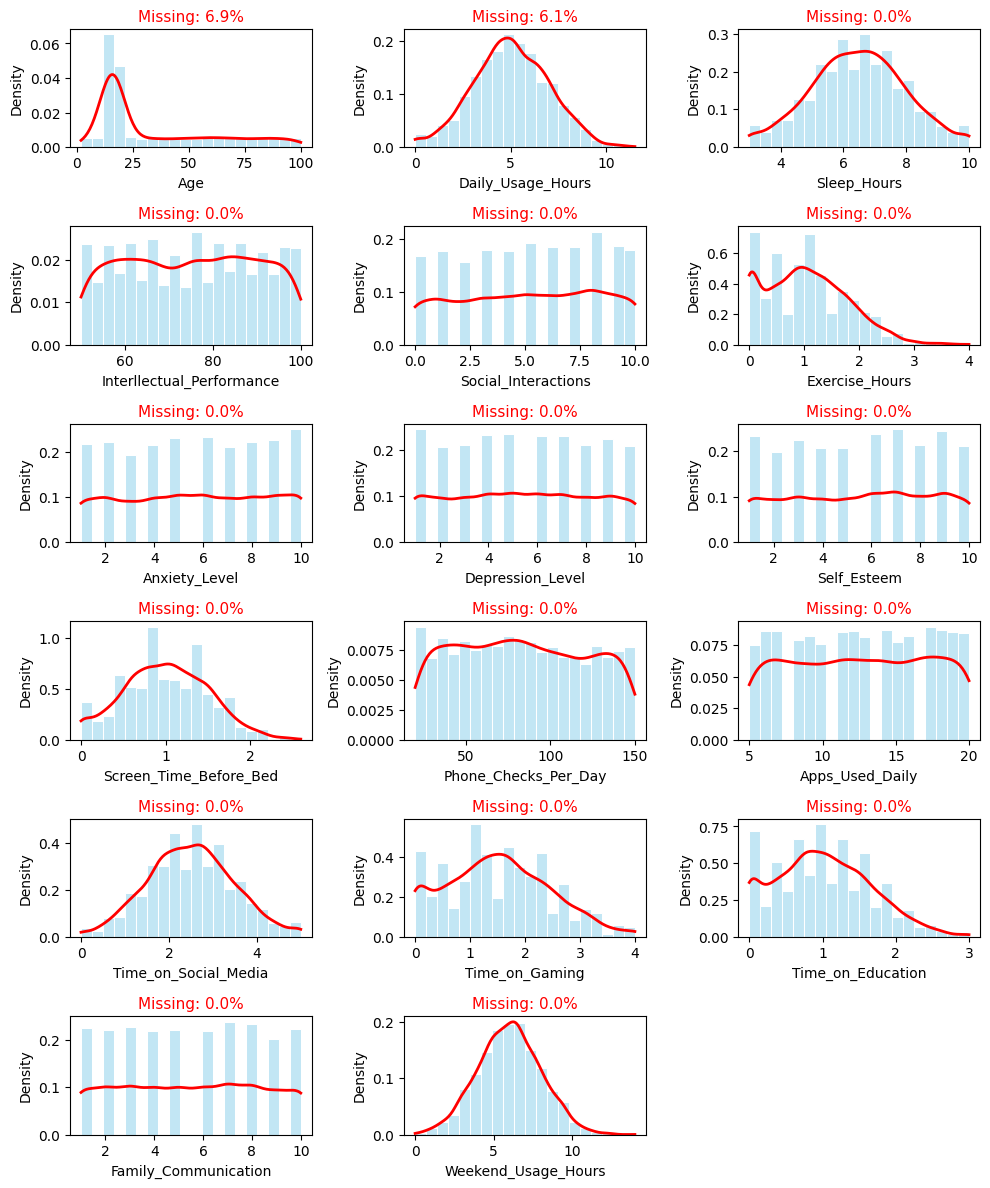

In [ ]:
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(10
                    , rows * 2))

if "Addiction_Level" in num_col:
    num_col = num_col.drop("Addiction_Level")

for i, col in enumerate(num_col, 1):
    x = X_train[col].dropna()
    missing_pct = X_train[col].isna().mean() * 100

    ax = plt.subplot(rows, cols, i)

    sns.histplot(
        x,
        bins=20,
        stat="density",
        color="skyblue",
        edgecolor="white",
        kde=True,
        ax=ax,
    )

    for line in ax.lines:
        line.set_color("red")
        line.set_linewidth(2)

    plt.text(
        0.5, 1.1,
        f"Missing: {missing_pct:.1f}%",
        transform=plt.gca().transAxes,
        ha="center", va="center",
        fontsize=11, color="red"
    )

plt.tight_layout()
plt.show()


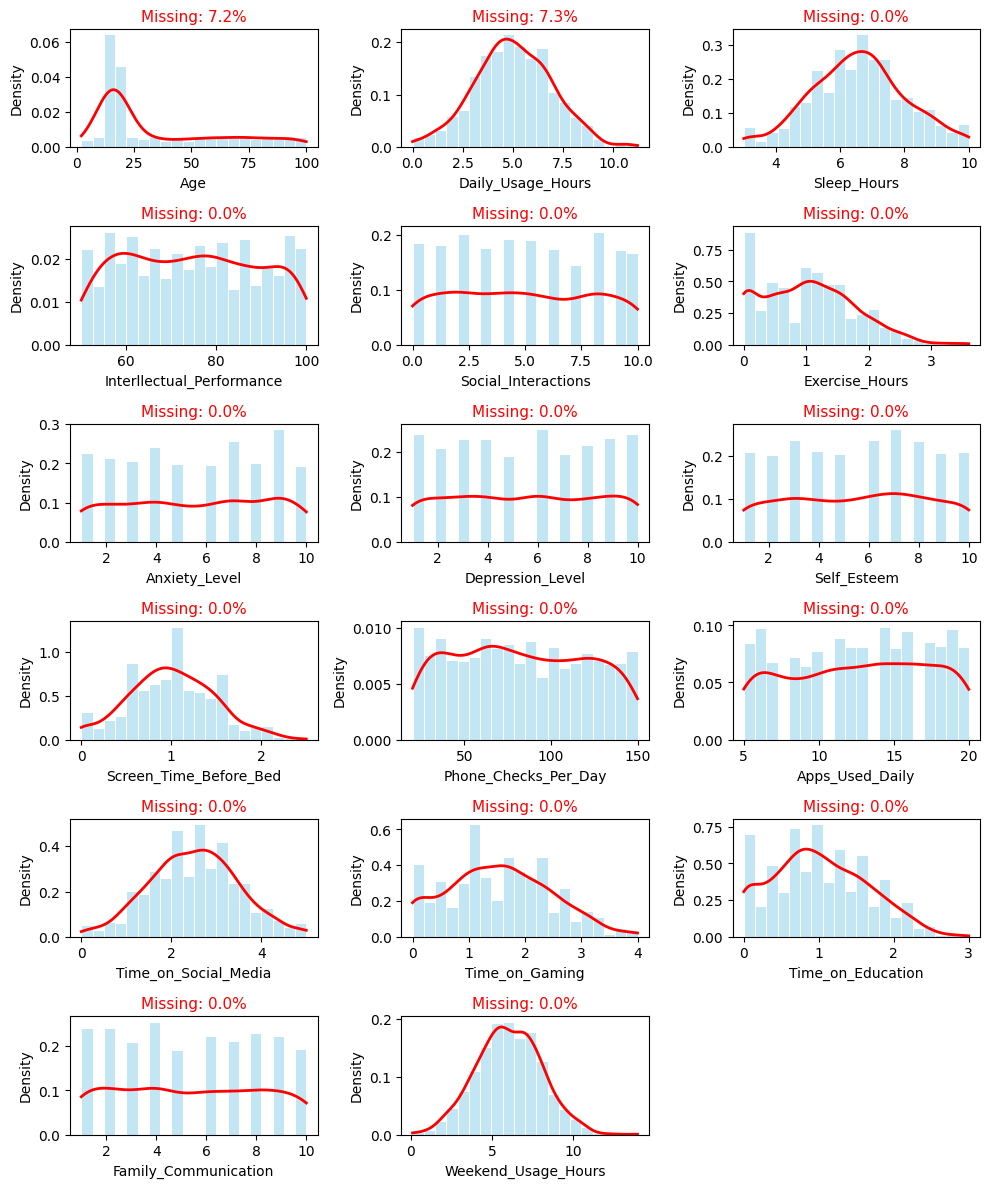

In [ ]:
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(10
                    , rows * 2))

if "Addiction_Level" in num_col:
    num_col = num_col.drop("Addiction_Level")

for i, col in enumerate(num_col, 1):
    x = X_test[col].dropna()
    missing_pct = X_test[col].isna().mean() * 100

    ax = plt.subplot(rows, cols, i)

    sns.histplot(
        x,
        bins=20,
        stat="density",
        color="skyblue",
        edgecolor="white",
        kde=True,
        ax=ax,
    )

    for line in ax.lines:
        line.set_color("red")
        line.set_linewidth(2)

    plt.text(
        0.5, 1.1,
        f"Missing: {missing_pct:.1f}%",
        transform=plt.gca().transAxes,
        ha="center", va="center",
        fontsize=11, color="red"
    )

plt.tight_layout()
plt.show()


Many of the distribution is uniform and does not follow normal even some are heavily skewed (e.g., `Age`), median imputation will be used for simple but safe imputation.

In [ ]:
print(TARGET in num_col)

for col in num_col:
    median_fill = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_fill)
    X_test[col]  = X_test[col].fillna(median_fill)

False


In [ ]:
X_train[num_col].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4805 entries, 4629 to 5462
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        4805 non-null   float64
 1   Daily_Usage_Hours          4805 non-null   float64
 2   Sleep_Hours                4805 non-null   float64
 3   Interllectual_Performance  4805 non-null   int64  
 4   Social_Interactions        4805 non-null   int64  
 5   Exercise_Hours             4805 non-null   float64
 6   Anxiety_Level              4805 non-null   int64  
 7   Depression_Level           4805 non-null   int64  
 8   Self_Esteem                4805 non-null   int64  
 9   Screen_Time_Before_Bed     4805 non-null   float64
 10  Phone_Checks_Per_Day       4805 non-null   int64  
 11  Apps_Used_Daily            4805 non-null   int64  
 12  Time_on_Social_Media       4805 non-null   float64
 13  Time_on_Gaming             4805 non-null   float64

### Categorical

In [ ]:
for col in cat_col:
    series = X_train[col]

    missing_count = series.isna().sum()
    missing_pct   = series.isna().mean() * 100

    print(f"\n=== {col} (Missing: {missing_count} = {missing_pct:.2f}%) ===")

    print(series.value_counts(dropna=True))


=== Gender (Missing: 97 = 2.02%) ===
Gender
Female    2229
Male      1369
Other     1110
Name: count, dtype: int64

=== Phone_Usage_Purpose (Missing: 90 = 1.87%) ===
Phone_Usage_Purpose
Gaming          1408
Browsing         882
Other            840
Education        805
Social Media     780
Name: count, dtype: int64


In [ ]:
for col in cat_col:
    series = X_test[col]

    missing_count = series.isna().sum()
    missing_pct   = series.isna().mean() * 100

    print(f"\n=== {col} (Missing: {missing_count} = {missing_pct:.2f}%) ===")

    print(series.value_counts(dropna=True))


=== Gender (Missing: 22 = 1.83%) ===
Gender
Female    552
Male      352
Other     276
Name: count, dtype: int64

=== Phone_Usage_Purpose (Missing: 33 = 2.75%) ===
Phone_Usage_Purpose
Gaming          358
Other           230
Education       196
Browsing        193
Social Media    192
Name: count, dtype: int64


Since the missing value in both columns are minor, it will be filled with mode.

In [ ]:
for col in cat_col:
    mode = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode)
    X_test[col]  = X_test[col].fillna(mode)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4805 entries, 4629 to 5462
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        4805 non-null   float64
 1   Gender                     4805 non-null   object 
 2   Daily_Usage_Hours          4805 non-null   float64
 3   Sleep_Hours                4805 non-null   float64
 4   Interllectual_Performance  4805 non-null   int64  
 5   Social_Interactions        4805 non-null   int64  
 6   Exercise_Hours             4805 non-null   float64
 7   Anxiety_Level              4805 non-null   int64  
 8   Depression_Level           4805 non-null   int64  
 9   Self_Esteem                4805 non-null   int64  
 10  Screen_Time_Before_Bed     4805 non-null   float64
 11  Phone_Checks_Per_Day       4805 non-null   int64  
 12  Apps_Used_Daily            4805 non-null   int64  
 13  Time_on_Social_Media       4805 non-null   float64

In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1202 entries, 5852 to 394
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1202 non-null   float64
 1   Gender                     1202 non-null   object 
 2   Daily_Usage_Hours          1202 non-null   float64
 3   Sleep_Hours                1202 non-null   float64
 4   Interllectual_Performance  1202 non-null   int64  
 5   Social_Interactions        1202 non-null   int64  
 6   Exercise_Hours             1202 non-null   float64
 7   Anxiety_Level              1202 non-null   int64  
 8   Depression_Level           1202 non-null   int64  
 9   Self_Esteem                1202 non-null   int64  
 10  Screen_Time_Before_Bed     1202 non-null   float64
 11  Phone_Checks_Per_Day       1202 non-null   int64  
 12  Apps_Used_Daily            1202 non-null   int64  
 13  Time_on_Social_Media       1202 non-null   float64


## Outliers

As what have been mentioned in the early data preprocessing section, outliers are minor and treated as data variability

## Duplicates

Some duplicates could be produced due to preprocessing steps, duplicates will be dropped from train only, since test should simulate.

In [ ]:
traincheck = pd.concat([X_train, y_train], axis=1)
traincheck.duplicated().sum()

np.int64(21)

In [ ]:
X_train.duplicated().sum()

np.int64(21)

In [ ]:
df = pd.concat([X_train, y_train], axis=1).drop_duplicates()

X_train = df.drop(columns=[y_train.name])
y_train = df[y_train.name]

# FEATURE ENGINEERING

## Encoding

In [ ]:
for col in cat_col:
    series = X_train[col]
    print(series.unique())

for col in cat_col:
    series = X_test[col]
    print(series.unique())

['Female' 'Other' 'Male']
['Gaming' 'Education' 'Browsing' 'Social Media' 'Other']
['Male' 'Female' 'Other']
['Browsing' 'Social Media' 'Education' 'Gaming' 'Other']


Both train and test has the same category for all categorical feature, and since the cardinality is low, one hot encode with dropping the "Other" column is wise.

In [ ]:
cat_cols = ["Gender", "Phone_Usage_Purpose"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

ohe = OneHotEncoder(
    drop=["Other", "Other"],
    sparse_output=False,
    handle_unknown="ignore"
)

ohe.fit(X_train[cat_cols])

X_train_ohe = pd.DataFrame(
    ohe.transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_train = pd.concat([X_train[num_cols], X_train_ohe], axis=1)

X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

X_test = pd.concat([X_test[num_cols], X_test_ohe], axis=1)

X_train.info()
X_test.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4784 entries, 4629 to 5462
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               4784 non-null   float64
 1   Daily_Usage_Hours                 4784 non-null   float64
 2   Sleep_Hours                       4784 non-null   float64
 3   Interllectual_Performance         4784 non-null   int64  
 4   Social_Interactions               4784 non-null   int64  
 5   Exercise_Hours                    4784 non-null   float64
 6   Anxiety_Level                     4784 non-null   int64  
 7   Depression_Level                  4784 non-null   int64  
 8   Self_Esteem                       4784 non-null   int64  
 9   Screen_Time_Before_Bed            4784 non-null   float64
 10  Phone_Checks_Per_Day              4784 non-null   int64  
 11  Apps_Used_Daily                   4784 non-null   int64  
 12  Time_on_

## New Features

In [ ]:
eps = 1e-3

for x in [X_train, X_test]:

    x["usage_zero_flag"] = (x["Daily_Usage_Hours"] <= 0).astype(int)

    denom_usage = x["Daily_Usage_Hours"].clip(lower=1)

    x["checks_per_hour"] = x["Phone_Checks_Per_Day"] / denom_usage
    x["apps_per_hour"] = x["Apps_Used_Daily"] / denom_usage
    x["screen_before_bed_ratio"] = x["Screen_Time_Before_Bed"] / denom_usage

    x["usage_to_sleep_ratio"] = x["Daily_Usage_Hours"] / (x["Sleep_Hours"] + eps)
    x["late_screen_ratio"] = x["Screen_Time_Before_Bed"] / (x["Sleep_Hours"] + eps)

    solo_usage = x["Time_on_Gaming"] + x["Time_on_Social_Media"]
    social_use = x["Family_Communication"] + x["Social_Interactions"]
    x["social_to_solo_ratio"] = social_use / (solo_usage + eps)

    mental_strain = x["Anxiety_Level"] + x["Depression_Level"]
    x["resilience_gap"] = x["Self_Esteem"] - mental_strain / 2.0

    x["high_gaming_x_sleep"] = x["Time_on_Gaming"] * x["Sleep_Hours"]
    x["social_media_x_anxiety"] = x["Time_on_Social_Media"] * x["Anxiety_Level"]


## Transform

In [ ]:
num_col = X_train.select_dtypes(include=["number"]).columns

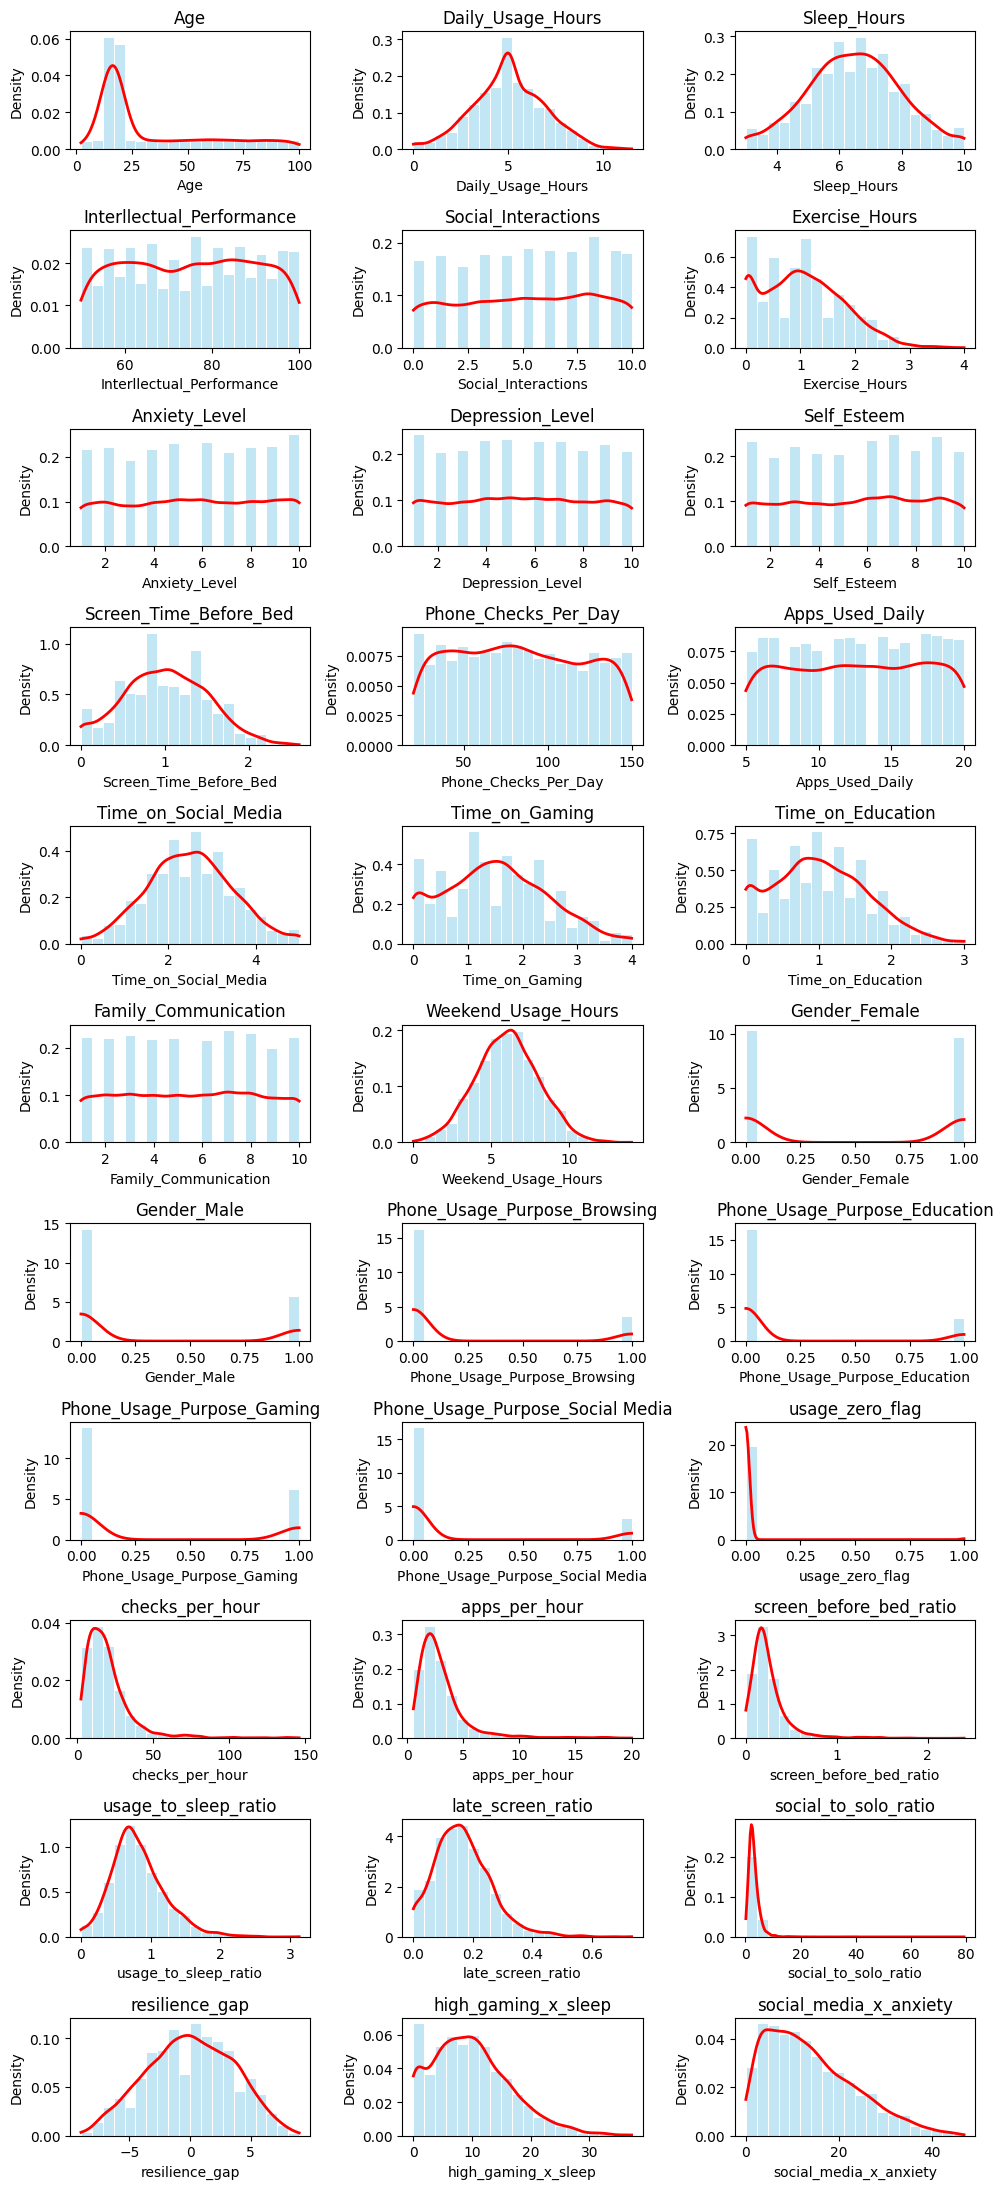

In [ ]:
cols = 3
n = len(num_col)
rows = int(np.ceil(n / cols))

plt.figure(figsize=(10, rows * 2))

if "Addiction_Level" in num_col:
    num_col = num_col.drop("Addiction_Level")

for i, col in enumerate(num_col, 1):
    ax = plt.subplot(rows, cols, i)

    sns.histplot(
        X_train[col],
        bins=20,
        stat="density",
        color="skyblue",
        edgecolor="white",
        kde=True,
        ax=ax,
    )

    for line in ax.lines:
        line.set_color("red")
        line.set_linewidth(2)

    ax.set_title(col)

plt.tight_layout()
plt.show()


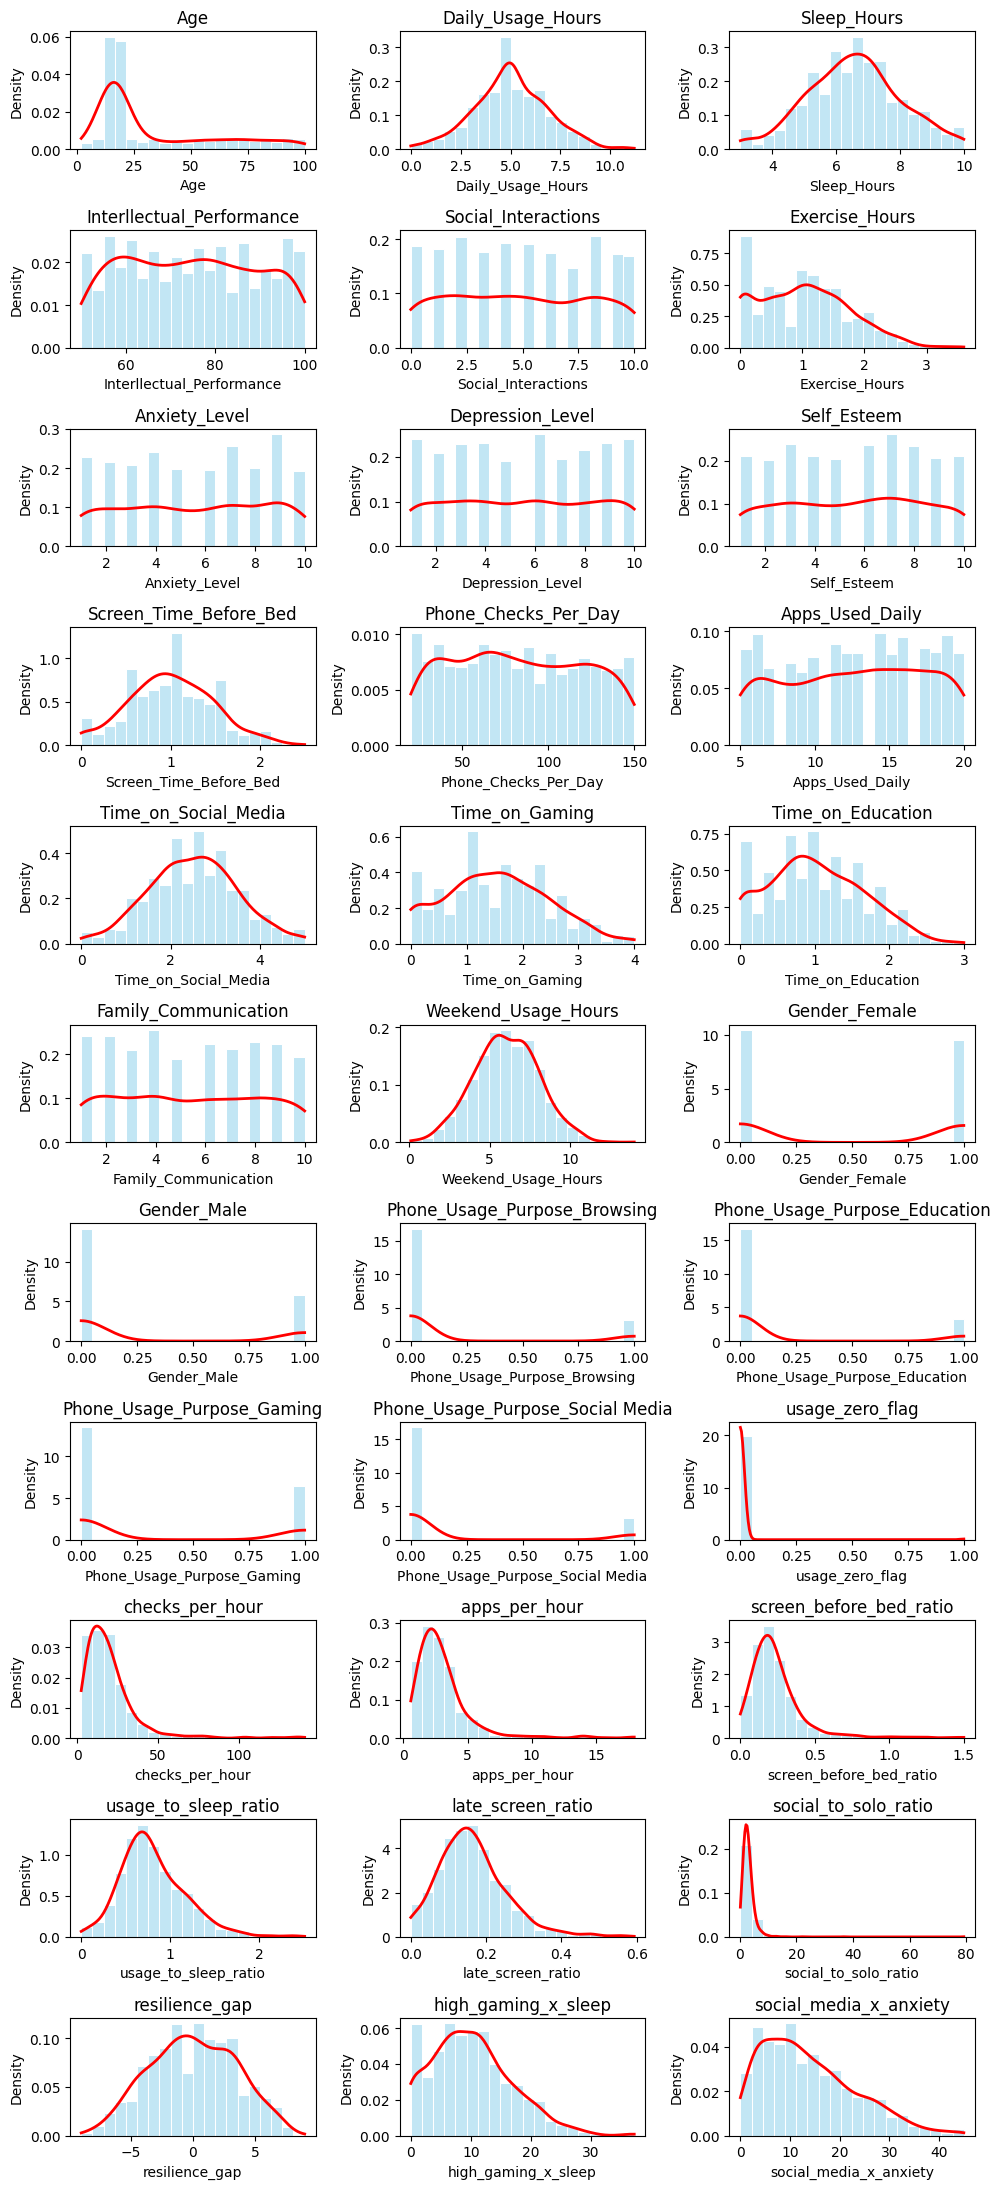

In [ ]:
cols = 3
n = len(num_col)
rows = int(np.ceil(n / cols))

plt.figure(figsize=(10, rows * 2))

if "Addiction_Level" in num_col:
    num_col = num_col.drop("Addiction_Level")

for i, col in enumerate(num_col, 1):
    ax = plt.subplot(rows, cols, i)

    sns.histplot(
        X_test[col],
        bins=20,
        stat="density",
        color="skyblue",
        edgecolor="white",
        kde=True,
        ax=ax,
    )

    for line in ax.lines:
        line.set_color("red")
        line.set_linewidth(2)

    ax.set_title(col)

plt.tight_layout()
plt.show()


Some numeric columns are skewed, such as `Age`, `checks_per_hour`, `apps_per_hour`, `screen_before_bed_ratio`, `usage_to_sleep_ratio`, `late_screen_ratio`, `social_to_solo_ratio`, and `social_media_x_anxiety`. The discrete or flag features by default are not well distributed. The skewed distribution should be log-transformed.

In [ ]:
skewed_cols = [
    "Age",
    "checks_per_hour",
    "apps_per_hour",
    "screen_before_bed_ratio",
    "usage_to_sleep_ratio",
    "social_to_solo_ratio",
    "social_media_x_anxiety"
]

for x in [X_train, X_test]:
    for col in skewed_cols:
        x[col] = np.log1p(x[col].clip(lower=0))


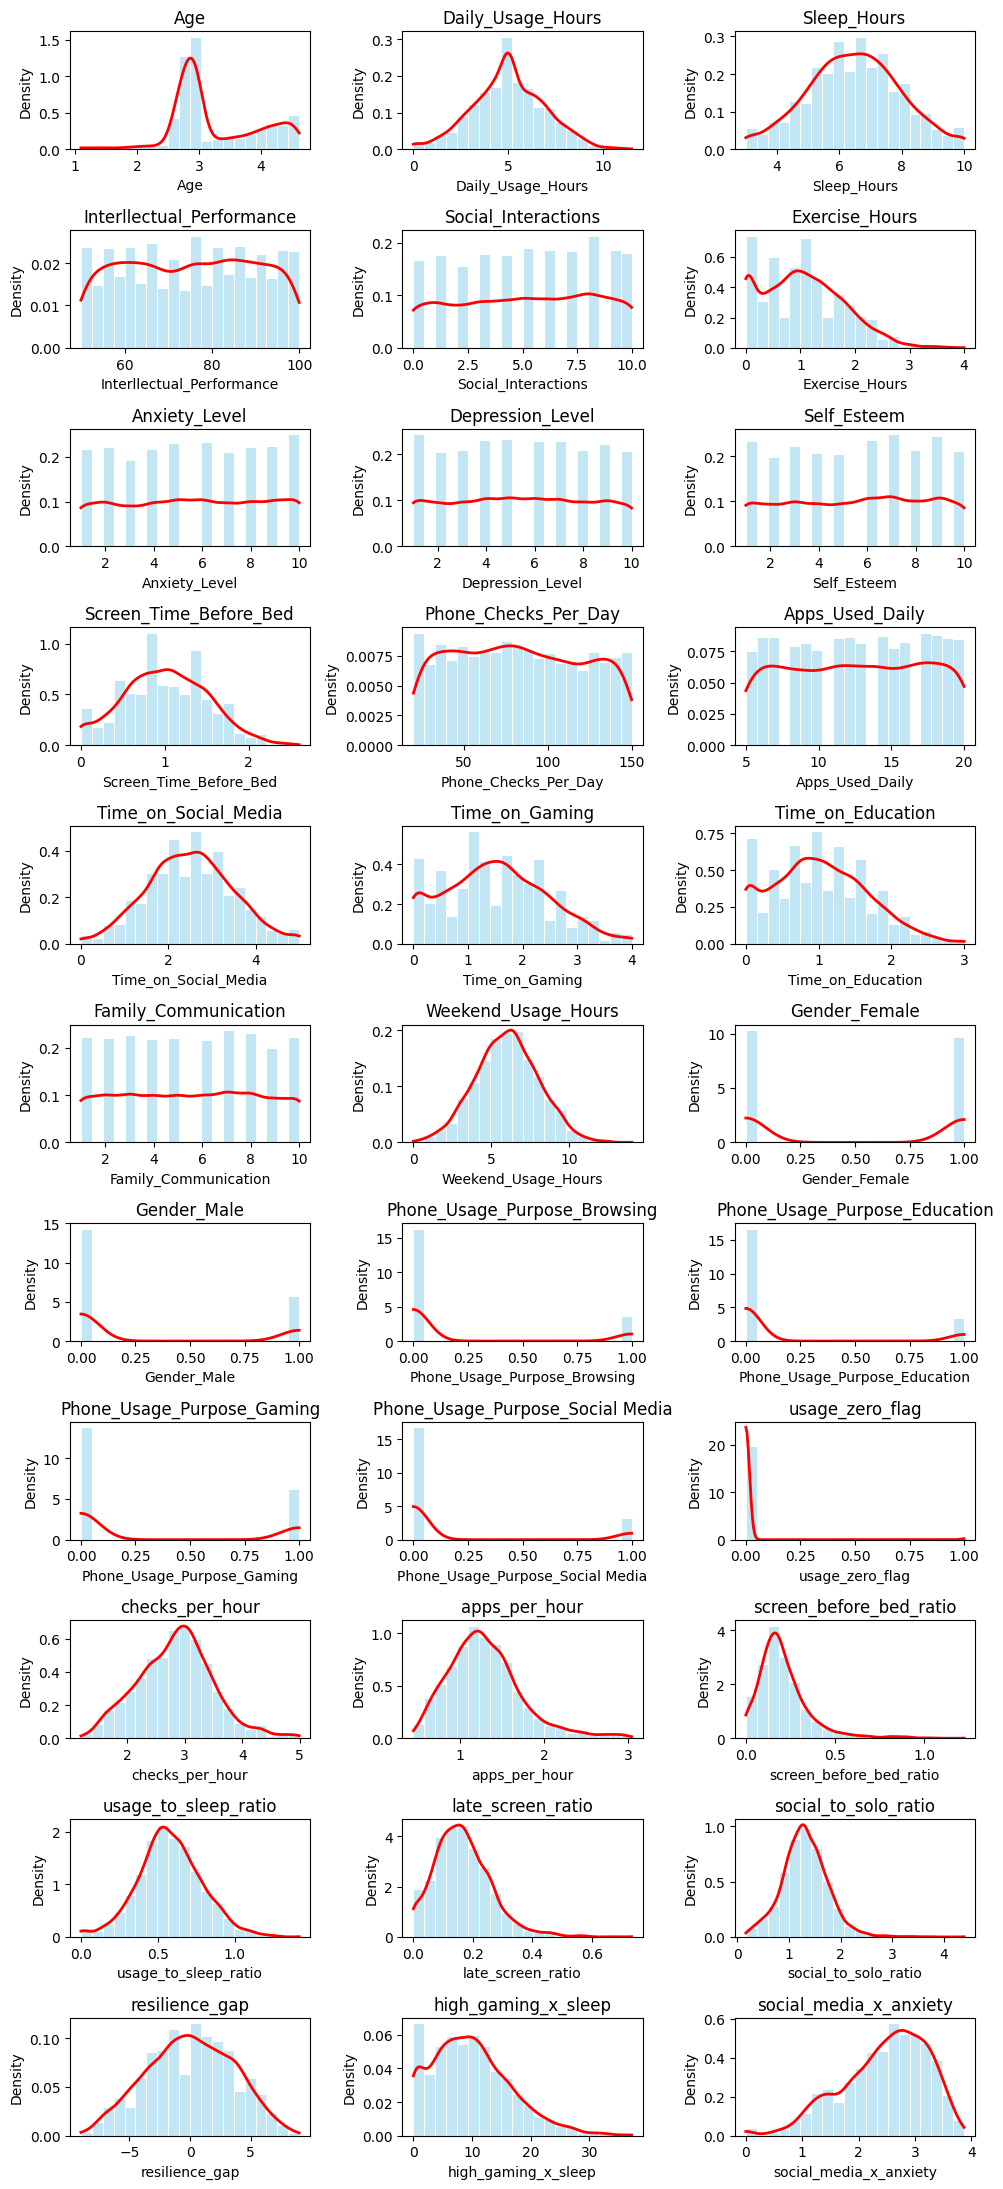

In [ ]:
cols = 3
n = len(num_col)
rows = int(np.ceil(n / cols))

plt.figure(figsize=(10, rows * 2))

if "Addiction_Level" in num_col:
    num_col = num_col.drop("Addiction_Level")

for i, col in enumerate(num_col, 1):
    ax = plt.subplot(rows, cols, i)

    sns.histplot(
        X_train[col],
        bins=20,
        stat="density",
        color="skyblue",
        edgecolor="white",
        kde=True,
        ax=ax,
    )

    for line in ax.lines:
        line.set_color("red")
        line.set_linewidth(2)

    ax.set_title(col)

plt.tight_layout()
plt.show()


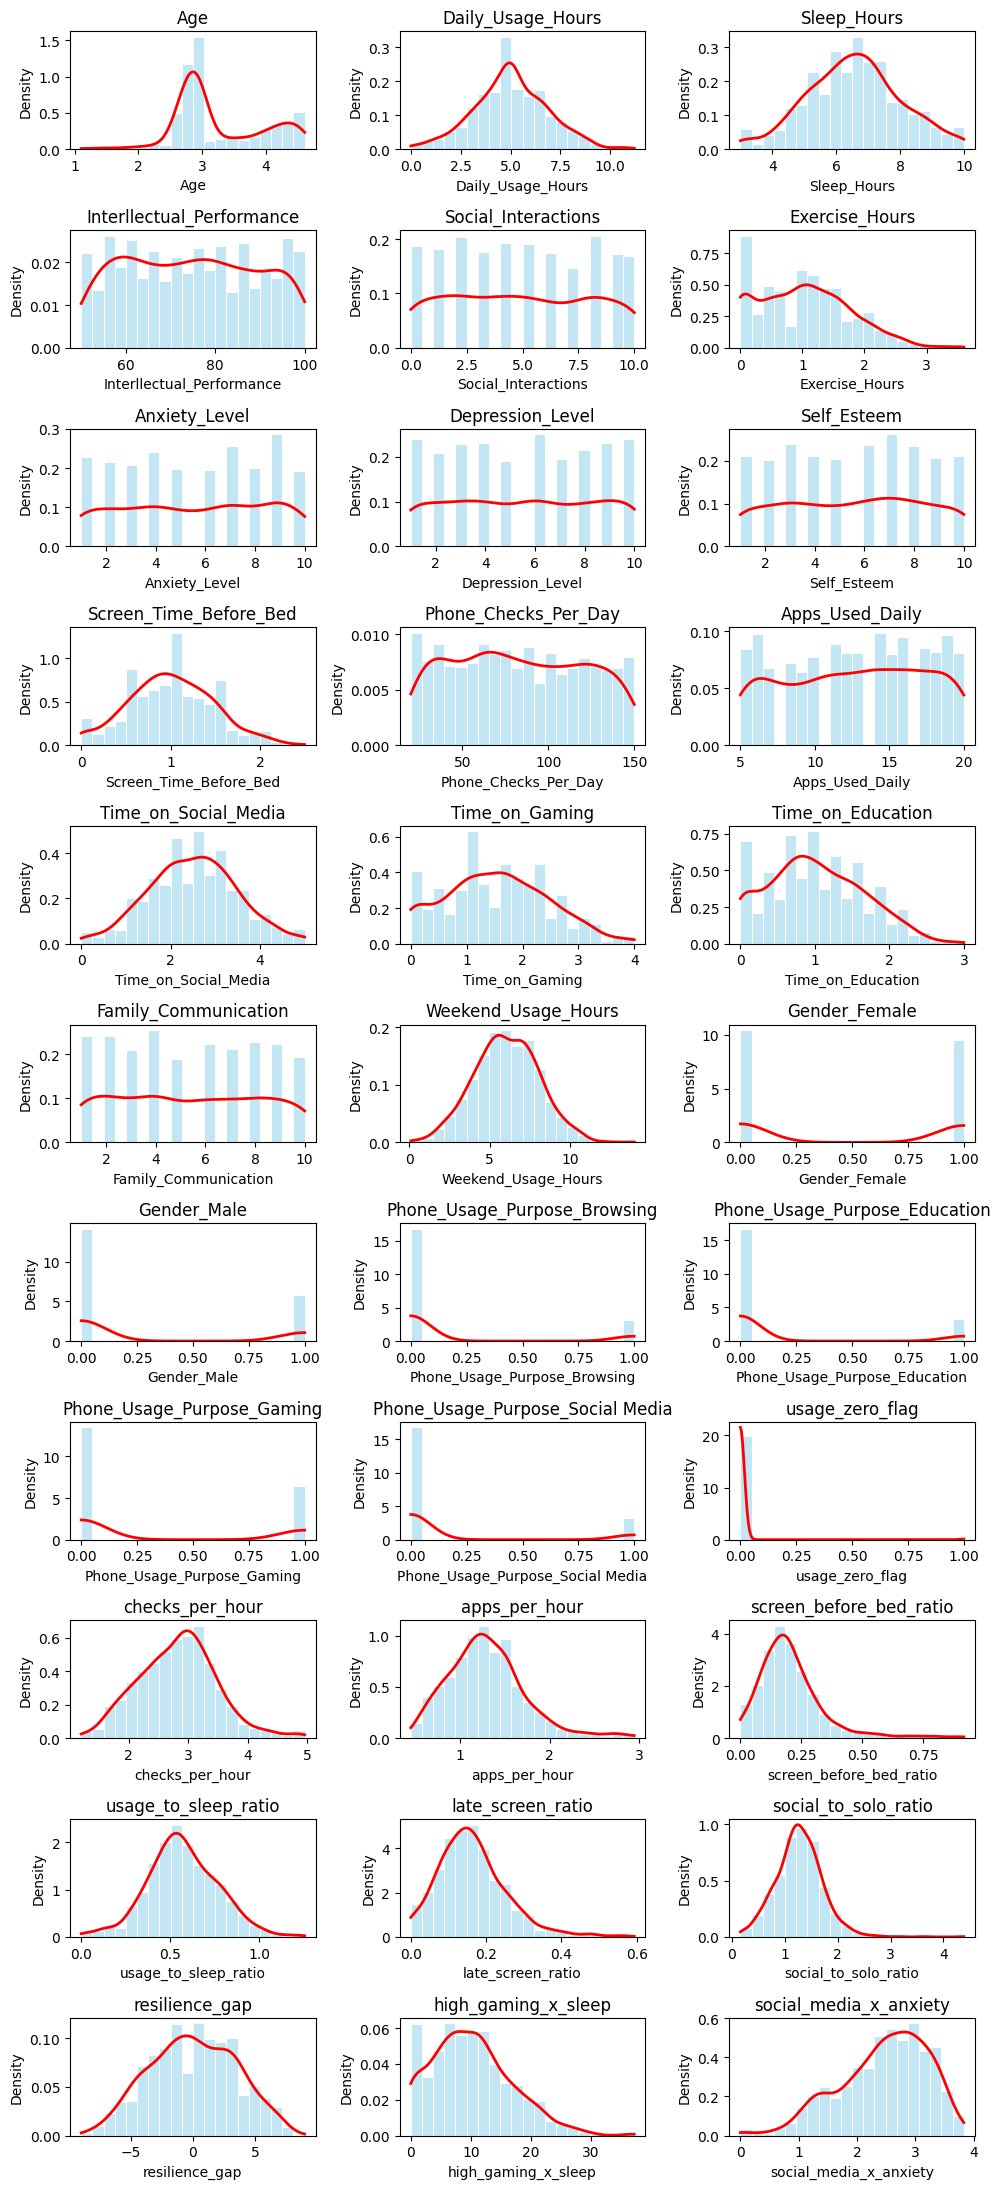

In [ ]:
cols = 3
n = len(num_col)
rows = int(np.ceil(n / cols))

plt.figure(figsize=(10, rows * 2))

if "Addiction_Level" in num_col:
    num_col = num_col.drop("Addiction_Level")

for i, col in enumerate(num_col, 1):
    ax = plt.subplot(rows, cols, i)

    sns.histplot(
        X_test[col],
        bins=20,
        stat="density",
        color="skyblue",
        edgecolor="white",
        kde=True,
        ax=ax,
    )

    # Make KDE line red & thicker
    for line in ax.lines:
        line.set_color("red")
        line.set_linewidth(2)

    ax.set_title(col)

plt.tight_layout()
plt.show()


## Scaling

In [ ]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [ ]:
X_train.head()
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4784 entries, 4629 to 5462
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               4784 non-null   float64
 1   Daily_Usage_Hours                 4784 non-null   float64
 2   Sleep_Hours                       4784 non-null   float64
 3   Interllectual_Performance         4784 non-null   float64
 4   Social_Interactions               4784 non-null   float64
 5   Exercise_Hours                    4784 non-null   float64
 6   Anxiety_Level                     4784 non-null   float64
 7   Depression_Level                  4784 non-null   float64
 8   Self_Esteem                       4784 non-null   float64
 9   Screen_Time_Before_Bed            4784 non-null   float64
 10  Phone_Checks_Per_Day              4784 non-null   float64
 11  Apps_Used_Daily                   4784 non-null   float64
 12  Time_on_

In [ ]:
X_test.head()

,Age,Daily_Usage_Hours,Sleep_Hours,Interllectual_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Screen_Time_Before_Bed,...,usage_zero_flag,checks_per_hour,apps_per_hour,screen_before_bed_ratio,usage_to_sleep_ratio,late_screen_ratio,social_to_solo_ratio,resilience_gap,high_gaming_x_sleep,social_media_x_anxiety
5852,0.752532,0.149579,0.021712,0.748130,0.271845,0.350240,0.138549,0.542459,-1.584572,-0.013632,...,-0.091824,0.088317,-0.854904,-0.248188,0.082175,-0.120677,-0.037898,-1.546544,1.443355,-0.945691
393,-0.676411,0.623023,-0.245650,-0.000954,0.271845,-1.145177,0.829704,-0.857096,-1.236199,0.387704,...,-0.091824,-0.395656,-1.062260,-0.220241,0.585727,0.329356,0.628176,-0.986622,-0.561232,0.546692
1089,-0.767575,0.149579,0.756959,0.135243,0.271845,-0.737336,1.175281,1.592126,1.550783,2.795721,...,-0.091824,0.492570,0.104785,1.123711,-0.240116,1.579290,0.160355,0.133221,1.141171,1.191699
4727,0.815322,-0.166051,-0.379332,0.339539,1.548418,-1.281124,-1.243761,-0.857096,0.157292,-0.615637,...,-0.091824,0.908710,-0.514982,-0.480675,0.032290,-0.490207,-0.182331,0.973104,0.909297,-0.814678
5314,-1.340317,-0.060841,0.422756,-1.090530,-1.643014,0.486187,1.520858,-1.206985,-0.887826,0.187036,...,-0.091824,0.545426,0.653398,-0.045269,-0.260597,-0.109283,-1.413520,-0.846642,1.075348,1.149594


## Dimensionality Reduction

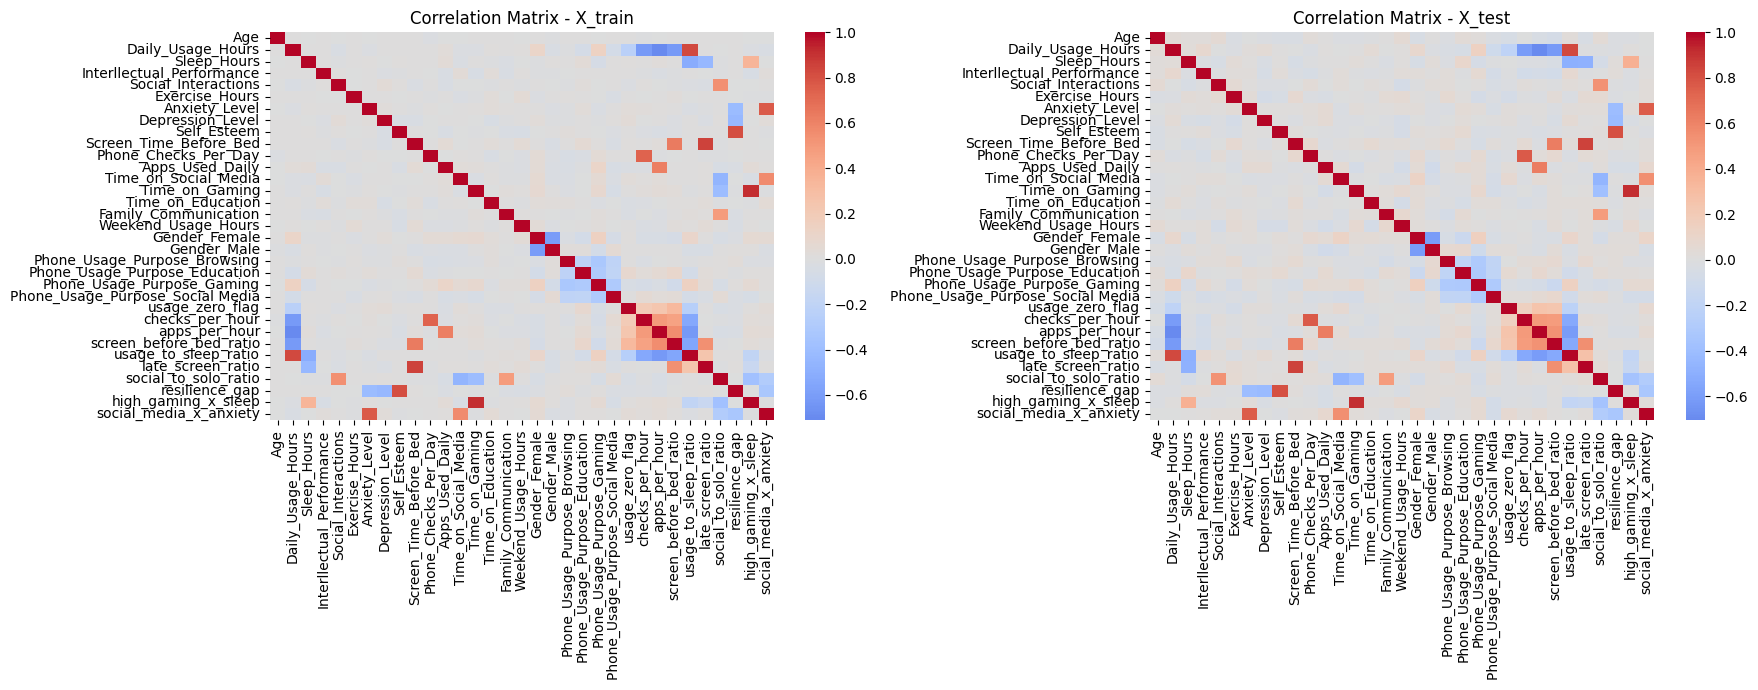

In [ ]:
corr_train = X_train.corr()
corr_test  = X_test.corr()

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_train, ax=axes[0], cmap="coolwarm", center=0)
axes[0].set_title("Correlation Matrix - X_train")

sns.heatmap(corr_test, ax=axes[1], cmap="coolwarm", center=0)
axes[1].set_title("Correlation Matrix - X_test")

plt.tight_layout()
plt.show()


Most features are not correlated meanign no collinearity problems.

In [ ]:
for x in [X_train, X_test]:
  corr = x.corr().abs()

  threshold = 0.80

  pairs = []

  for i in range(len(corr.columns)):
      for j in range(i + 1, len(corr.columns)):
          value = corr.iloc[i, j]
          if value >= threshold:
              f1 = corr.columns[i]
              f2 = corr.columns[j]
              pairs.append((f1, f2, value))

  print("Highly correlated feature pairs (corr >= 0.80):")
  for f1, f2, value in pairs:
      print(f"{f1}  <-->  {f2}   | corr = {value:.3f}")
  print("="*30)


Highly correlated feature pairs (corr >= 0.80):
Daily_Usage_Hours  <-->  usage_to_sleep_ratio   | corr = 0.829
Self_Esteem  <-->  resilience_gap   | corr = 0.818
Screen_Time_Before_Bed  <-->  late_screen_ratio   | corr = 0.850
Time_on_Gaming  <-->  high_gaming_x_sleep   | corr = 0.915
Highly correlated feature pairs (corr >= 0.80):
Daily_Usage_Hours  <-->  usage_to_sleep_ratio   | corr = 0.830
Self_Esteem  <-->  resilience_gap   | corr = 0.805
Screen_Time_Before_Bed  <-->  late_screen_ratio   | corr = 0.852
Time_on_Gaming  <-->  high_gaming_x_sleep   | corr = 0.914


All highly correlated features are the result of intentional feature engineering, hence should be left as it is.

# MODELING

In [ ]:
print(X_train.shape)
print(y_train.shape)

(4784, 33)
(4784,)


In [ ]:
print(X_test.shape)
print(y_test.shape)

(1202, 33)
(1202,)


## Initializing Helper Functions and Variables

### Device configuration

In [ ]:
def has_xgb_gpu():
    try:
        xgb.XGBRegressor(tree_method="gpu_hist").fit(
            np.random.rand(10, 3),
            np.random.rand(10),
            verbose=False
        )
        return True
    except:
        return False

def has_lgb_gpu():
    try:
        m = lgb.LGBMRegressor(device_type="gpu", n_estimators=10)
        m.fit(np.random.rand(20, 3), np.random.rand(20))
        return True
    except:
        return False

def has_cat_gpu():
    try:
        m = CatBoostRegressor(task_type="GPU", iterations=1)
        m.fit(np.random.rand(20, 3), np.random.rand(20), verbose=False)
        return True
    except:
        return False

XGB_USE_GPU = has_xgb_gpu()
LGB_USE_GPU = has_lgb_gpu()
CAT_USE_GPU = has_cat_gpu()

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 20, number of used features: 0


### Base model tuning function

Defining list for tracking performance across optuna trials.

In [ ]:
N_TRIALS = 20

rmse_history_lr  = []
rmse_history_dt  = []
rmse_history_rf  = []
rmse_history_xgb = []
rmse_history_lgb = []
rmse_history_cat = []

r2_history_lr  = []
r2_history_dt  = []
r2_history_rf  = []
r2_history_xgb = []
r2_history_lgb = []
r2_history_cat = []

#### Linear Regression


In [ ]:
def tune_lr(X, y):
    def objective(trial):
        # Ridge only has alpha as main HP
        alpha = trial.suggest_float("alpha", 1e-6, 10.0, log=True)

        kf = KFold(n_splits=5, shuffle=True, random_state=seed)

        all_true, all_pred = [], []

        for tr, va in kf.split(X):
            model = Ridge(alpha=alpha, random_state=seed)
            model.fit(X.iloc[tr], y.iloc[tr])
            pred = model.predict(X.iloc[va])

            all_true.extend(y.iloc[va])
            all_pred.extend(pred)

        mse = mean_squared_error(all_true, all_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(all_true, all_pred)

        rmse_history_lr.append(rmse)
        r2_history_lr.append(r2)

        return rmse

    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    return study.best_params

#### Decision Tree Regressor

In [ ]:
def tune_dt(X, y):
    def objective(trial):
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 40),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_float("max_features", 0.5, 1.0),
            "random_state": seed
        }

        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        all_true, all_pred = [], []

        for tr, va in kf.split(X):
            model = DecisionTreeRegressor(**params)
            model.fit(X.iloc[tr], y.iloc[tr])
            pred = model.predict(X.iloc[va])

            all_true.extend(y.iloc[va])
            all_pred.extend(pred)

        mse = mean_squared_error(all_true, all_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(all_true, all_pred)

        rmse_history_dt.append(rmse)
        r2_history_dt.append(r2)

        return rmse

    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    return study.best_params

#### Random Forest Regressor

In [ ]:
def tune_rf(X, y):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
            "max_depth": trial.suggest_int("max_depth", 5, 40),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_float("max_features", 0.5, 1.0),
            "bootstrap": True,
            "random_state": seed,
            "n_jobs": -1
        }

        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        all_true, all_pred = [], []

        for tr, va in kf.split(X):
            model = RandomForestRegressor(**params)
            model.fit(X.iloc[tr], y.iloc[tr])
            pred = model.predict(X.iloc[va])

            all_true.extend(y.iloc[va])
            all_pred.extend(pred)

        mse = mean_squared_error(all_true, all_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(all_true, all_pred)

        rmse_history_rf.append(rmse)
        r2_history_rf.append(r2)

        return rmse

    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    return study.best_params

#### XGBoost Regressor

In [ ]:
def tune_xgb(X, y):
    def objective(trial):
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "verbosity": 0,
            "tree_method": "gpu_hist" if XGB_USE_GPU else "hist",
            "random_state": seed,
            "seed": seed
        }

        kf = KFold(n_splits=5, shuffle=True, random_state=seed)

        all_true = []
        all_pred = []

        for tr, va in kf.split(X):
            model = xgb.XGBRegressor(**params)
            model.fit(X.iloc[tr], y.iloc[tr], verbose=False)
            pred = model.predict(X.iloc[va])

            all_true.extend(y.iloc[va])
            all_pred.extend(pred)

        mse = mean_squared_error(all_true, all_pred)
        mean_rmse = np.sqrt(mse)

        mean_r2   = r2_score(all_true, all_pred)

        rmse_history_xgb.append(mean_rmse)
        r2_history_xgb.append(mean_r2)

        return mean_rmse

    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    return study.best_params

#### LightGBM Regressor

In [ ]:
def tune_lgb(X, y):
    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "rmse",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 20, 150),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 40),
            "verbosity": -1,
            "device_type": "gpu" if LGB_USE_GPU else "cpu",
            "random_state": seed,
            "deterministic": True,
            "force_col_wise": True
        }

        kf = KFold(n_splits=5, shuffle=True, random_state=42)

        all_true = []
        all_pred = []

        for tr, va in kf.split(X):
            model = lgb.LGBMRegressor(**params)
            model.fit(X.iloc[tr], y.iloc[tr])
            pred = model.predict(X.iloc[va])

            all_true.extend(y.iloc[va])
            all_pred.extend(pred)

        mse = mean_squared_error(all_true, all_pred)
        mean_rmse = np.sqrt(mse)

        mean_r2   = r2_score(all_true, all_pred)

        rmse_history_lgb.append(mean_rmse)
        r2_history_lgb.append(mean_r2)

        return mean_rmse

    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    return study.best_params

#### CatBoost Regressor

In [ ]:
def tune_cat(X, y):
    def objective(trial):
        params = {
            "loss_function": "RMSE",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "depth": trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "iterations": trial.suggest_int("iterations", 300, 1200),
            "random_seed": seed,
            "task_type": "GPU" if CAT_USE_GPU else "CPU",
            "verbose": False,
            "bootstrap_type": "Bernoulli",
            "subsample": trial.suggest_float("subsample", 0.6, 1.0)
        }

        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        all_true, all_pred = [], []

        for tr, va in kf.split(X):
            model = CatBoostRegressor(**params)
            model.fit(X.iloc[tr], y.iloc[tr], verbose=False)
            pred = model.predict(X.iloc[va])

            all_true.extend(y.iloc[va])
            all_pred.extend(pred)

        mse = mean_squared_error(all_true, all_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(all_true, all_pred)

        rmse_history_cat.append(rmse)
        r2_history_cat.append(r2)

        return rmse

    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    return study.best_params

### Stacking best models function

In [ ]:
def stacking_general(X_train, y_train, X_test, model_dict, meta_model=None, seed=42):

    kf = KFold(n_splits=5, shuffle=True, random_state=seed)

    oof_preds = {name: np.zeros(len(X_train)) for name in model_dict}
    test_preds = {name: np.zeros(len(X_test)) for name in model_dict}

    cv_scores = {name: {"rmse": [], "r2": []} for name in model_dict}

    for fold, (tr, va) in enumerate(kf.split(X_train)):
        X_tr, y_tr = X_train.iloc[tr], y_train.iloc[tr]
        X_va, y_va = X_train.iloc[va], y_train.iloc[va]

        for name, model in model_dict.items():
            m = clone(model)
            if hasattr(m, "random_state"):
                m.random_state = seed
            m.fit(X_tr, y_tr)

            pred_va = m.predict(X_va)
            oof_preds[name][va] = pred_va
            test_preds[name] += m.predict(X_test) / kf.n_splits

            cv_scores[name]["rmse"].append(np.sqrt(mean_squared_error(y_va, pred_va)))
            cv_scores[name]["r2"].append(r2_score(y_va, pred_va))

    meta_train = pd.DataFrame(oof_preds)
    meta_test  = pd.DataFrame(test_preds)

    if meta_model is None:
        meta_model = lgb.LGBMRegressor(
            random_state=seed,
            deterministic=True,
            force_col_wise=True,
            verbosity=-1
        )

    meta_model.fit(meta_train, y_train)

    oof_meta = meta_model.predict(meta_train)

    rmse_meta = np.sqrt(mean_squared_error(y_train, oof_meta))
    r2_meta   = r2_score(y_train, oof_meta)

    return {
        "meta_train": meta_train,
        "meta_test":  meta_test,
        "cv_scores":  cv_scores,
        "meta_scores": {"rmse": rmse_meta, "r2": r2_meta},
        "meta_model": meta_model
    }

## Build Model (Fit)

### Tune base models and extract the best base models

In [ ]:
print("=== Tuning Linear Regression ===")
best_lr  = tune_lr(X_train, y_train)
print("=== Tuning Decision Tree ===")
best_dt  = tune_dt(X_train, y_train)
print("=== Tuning Random Forest ===")
best_rf  = tune_rf(X_train, y_train)
print("=== Tuning XGBoost ===")
best_xgb = tune_xgb(X_train, y_train)
print("=== Tuning LightGBM ===")
best_lgb = tune_lgb(X_train, y_train)
print("=== Tuning CatBoost ===")
best_cat = tune_cat(X_train, y_train)

full_model_dict = {
    "lr": Ridge(**best_lr, random_state=seed),
    "dt": DecisionTreeRegressor(**best_dt, random_state=seed),
    "rf": RandomForestRegressor(**best_rf, random_state=seed),
    "xgb": xgb.XGBRegressor(**best_xgb, random_state=seed),
    "lgb": lgb.LGBMRegressor(**best_lgb, random_state=seed),
    "cat": CatBoostRegressor(**best_cat, random_seed=seed, verbose=False)
}

=== Tuning Linear Regression ===


  0%|          | 0/20 [00:00<?, ?it/s]

=== Tuning Decision Tree ===


  0%|          | 0/20 [00:00<?, ?it/s]

=== Tuning Random Forest ===


...

  0%|          | 0/20 [00:00<?, ?it/s]

=== Tuning LightGBM ===


  0%|          | 0/20 [00:00<?, ?it/s]

=== Tuning CatBoost ===


  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
base_scores = {
    "lr":  min(rmse_history_lr),
    "dt":  min(rmse_history_dt),
    "rf":  min(rmse_history_rf),
    "xgb": min(rmse_history_xgb),
    "lgb": min(rmse_history_lgb),
    "cat": min(rmse_history_cat),
}

best3 = sorted(base_scores, key=base_scores.get)[:3]
print("Top 3:", best3)

model_dict_best3 = {name: full_model_dict[name] for name in best3}


Top 3: ['cat', 'lgb', 'xgb']


### Build Stack Model

In [ ]:
stack_result = stacking_general(
    X_train, y_train, X_test,
    model_dict=model_dict_best3,
    meta_model=lgb.LGBMRegressor(
        random_state=seed,
        deterministic=True,
        force_col_wise=True,
        verbosity=-1
    ),
    seed=seed
)

### Fit base models

In [ ]:
fitted_models = {}

for name, model in full_model_dict.items():
    m = model.__class__(**model.get_params())
    if hasattr(m, "random_state"):
        m.random_state = seed
    m.fit(X_train, y_train)
    fitted_models[name] = m

### Fit meta model

In [ ]:
meta_model = stack_result["meta_model"]
meta_model.fit(stack_result["meta_train"], y_train)
fitted_models["stacked"] = meta_model

## Predict

Prediction on both train and test to diagnose whether each model overfits

In [ ]:
train_predictions = {}
test_predictions  = {}

for name, model in fitted_models.items():
    if name == "stacked":
        train_pred = model.predict(stack_result["meta_train"])
    else:
        train_pred = model.predict(X_train)

    train_predictions[name] = train_pred

    if name == "stacked":
        test_pred = model.predict(stack_result["meta_test"])
    else:
        test_pred = model.predict(X_test)

    test_predictions[name] = test_pred

# MODEL EVALUATION

## Performance

### Optuna trials metrics

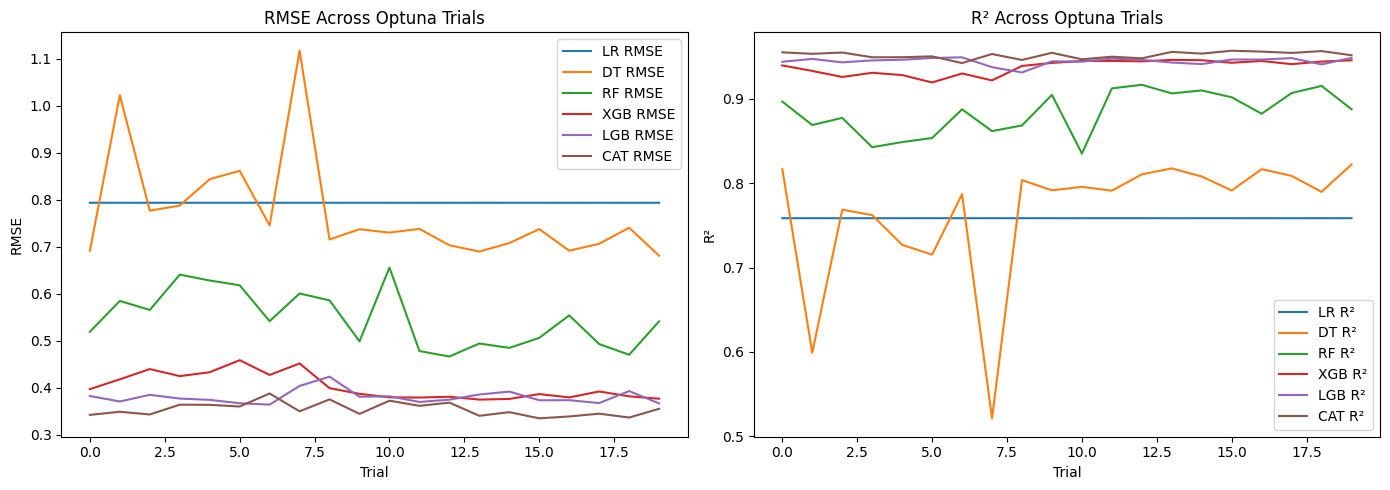

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes

ax1.plot(rmse_history_lr,  label="LR RMSE")
ax1.plot(rmse_history_dt,  label="DT RMSE")
ax1.plot(rmse_history_rf,  label="RF RMSE")
ax1.plot(rmse_history_xgb, label="XGB RMSE")
ax1.plot(rmse_history_lgb, label="LGB RMSE")
ax1.plot(rmse_history_cat, label="CAT RMSE")

ax1.set_title("RMSE Across Optuna Trials")
ax1.set_xlabel("Trial")
ax1.set_ylabel("RMSE")
ax1.legend()

ax2.plot(r2_history_lr,  label="LR R²")
ax2.plot(r2_history_dt,  label="DT R²")
ax2.plot(r2_history_rf,  label="RF R²")
ax2.plot(r2_history_xgb, label="XGB R²")
ax2.plot(r2_history_lgb, label="LGB R²")
ax2.plot(r2_history_cat, label="CAT R²")

ax2.set_title("R² Across Optuna Trials")
ax2.set_xlabel("Trial")
ax2.set_ylabel("R²")
ax2.legend()

plt.tight_layout()
plt.show()

The Optuna tuning curves provide a detailed view of how each model responds to hyperparameter optimization. LightGBM and CatBoost show the strongest and most stable convergence patterns, with RMSE values that remain consistently low across trials and R² values that stay high with only minor variation. This indicates that both models benefit from a smooth and well-structured hyperparameter landscape that allows Optuna to locate high-quality configurations efficiently. XGBoost also demonstrates clear performance improvement, but its curves display more trial-to-trial fluctuation in both RMSE and R². This behavior suggests that XGBoost is more sensitive to specific parameter combinations and that its search space contains more irregularities that cause temporary dips before performance stabilizes. Random Forest improves modestly during tuning but reaches a lower performance ceiling, which aligns with the fact that it has fewer impactful hyperparameters and tends to be less flexible than gradient boosting models. The Decision Tree model shows the most volatile behavior, with sharp spikes in error and abrupt drops in R², reflecting its high variance and strong dependence on depth and split parameters. Linear Regression remains perfectly flat, which is expected because it has no meaningful hyperparameters for Optuna to adjust. Overall, the tuning curves illustrate that the gradient boosting family, particularly LightGBM and CatBoost, provides the most reliable and consistently improving optimization trajectories, while XGBoost delivers competitive results with greater instability.

### Metrics on each fold in base model train-time

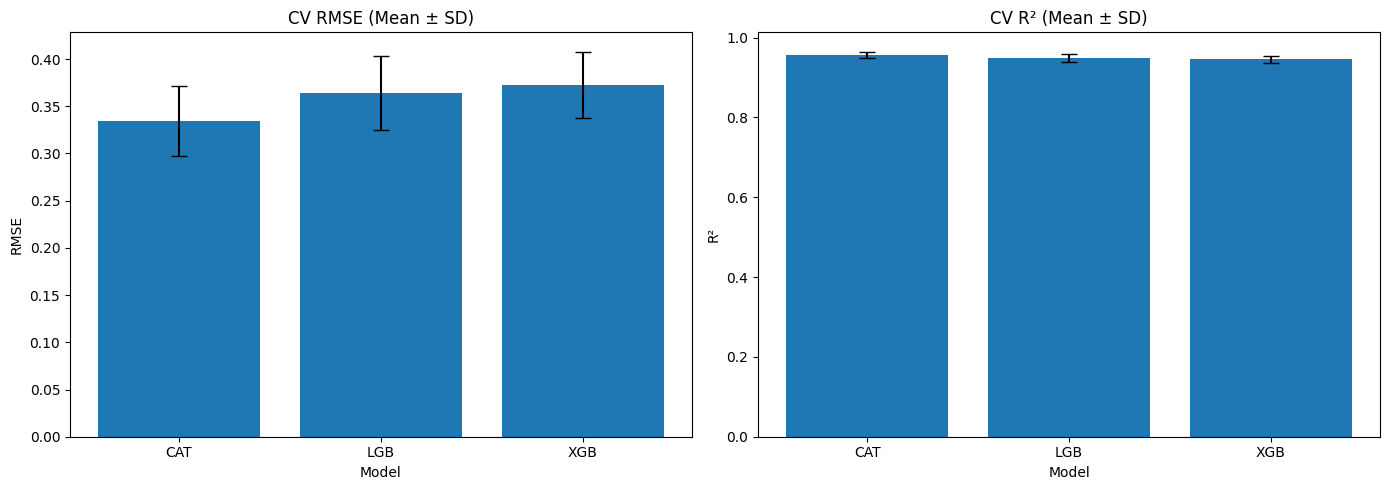

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax3, ax4 = axes

models = best3
labels = [m.upper() for m in models]

cv_rmse_means = [np.mean(stack_result["cv_scores"][m]["rmse"]) for m in models]
cv_rmse_stds  = [np.std (stack_result["cv_scores"][m]["rmse"]) for m in models]

cv_r2_means = [np.mean(stack_result["cv_scores"][m]["r2"]) for m in models]
cv_r2_stds  = [np.std (stack_result["cv_scores"][m]["r2"]) for m in models]

ax3.bar(
    labels,
    cv_rmse_means,
    yerr=cv_rmse_stds,
    capsize=6
)
ax3.set_title("CV RMSE (Mean ± SD)")
ax3.set_ylabel("RMSE")
ax3.set_xlabel("Model")

ax4.bar(
    labels,
    cv_r2_means,
    yerr=cv_r2_stds,
    capsize=6
)
ax4.set_title("CV R² (Mean ± SD)")
ax4.set_ylabel("R²")
ax4.set_xlabel("Model")

plt.tight_layout()
plt.show()

The cross-validation results show that CatBoost, LightGBM, and XGBoost all achieve strong and stable predictive performance, but the models differ in both absolute accuracy and consistency across folds. CatBoost attains the lowest mean RMSE, indicating that it produces the smallest average prediction errors among the three models. LightGBM and XGBoost follow closely, although both record slightly higher RMSE values. The standard deviations are small for all models, which suggests that the performance is robust and not highly affected by the choice of fold splits. The R² results reinforce this pattern. All models achieve very high coefficients of determination, consistently near 0.94 to 0.96, with minimal variation across folds. This indicates that each model is able to explain most of the variance in the target variable and demonstrates reliable generalization within the cross-validation framework. Taken together, the metrics confirm that all three gradient boosting models perform at a strong and comparable level, with CatBoost holding a modest advantage in error reduction and overall stability, followed closely by LightGBM and XGBoost.

### OOF Metrics

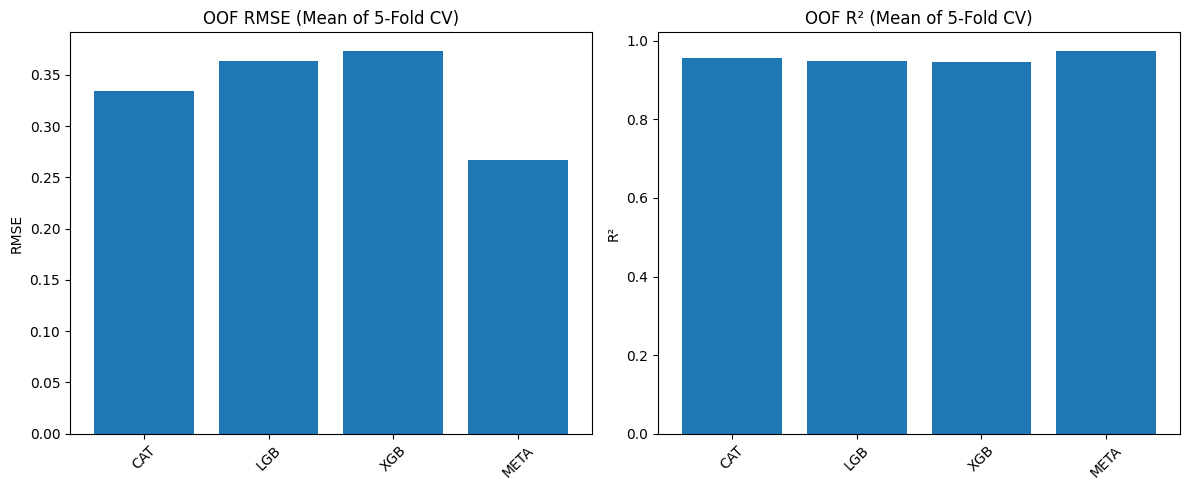

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax5, ax6 = axes

models = best3
labels = [m.upper() for m in models] + ["META"]

oof_rmse = [np.mean(stack_result["cv_scores"][m]["rmse"]) for m in models]
oof_r2   = [np.mean(stack_result["cv_scores"][m]["r2"])   for m in models]

oof_rmse.append(stack_result["meta_scores"]["rmse"])
oof_r2.append(stack_result["meta_scores"]["r2"])

ax5.bar(labels, oof_rmse)
ax5.set_title("OOF RMSE (Mean of 5-Fold CV)")
ax5.set_ylabel("RMSE")
ax5.set_xticklabels(labels, rotation=45)

ax6.bar(labels, oof_r2)
ax6.set_title("OOF R² (Mean of 5-Fold CV)")
ax6.set_ylabel("R²")
ax6.set_xticklabels(labels, rotation=45)

plt.tight_layout()
plt.show()

The out-of-fold results indicate that CatBoost, LightGBM, and XGBoost each demonstrate strong in-sample generalization, with RMSE values concentrated in the 0.33 to 0.38 range and R² values close to 0.94. CatBoost performs slightly better than the other two individual models, although the differences are relatively small. The stacked meta-model shows a noticeable improvement over all three base learners by reducing the OOF RMSE to roughly 0.27 and increasing the OOF R² to approximately 0.97. This improvement suggests that the meta-learner is able to capture complementary information from the base models and combine their strengths into a more accurate predictor. It also indicates that the OOF blending procedure was executed correctly, since the gains reflect the meta-model's ability to exploit cross-model diversity rather than artifacts of data leakage. Even so, OOF estimates remain internally generated and are therefore still tied to the training distribution. As a result, the final validation must rely on a fully held-out test set to verify that the stacked model's superior OOF performance translates into genuine improvements on unseen data.

### Metrics Summary

In [ ]:
def eval_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, r2, mae

models = ["lr", "dt", "rf", "xgb", "lgb", "cat", "stacked"]
rows = []

for name in models:
    rmse_tr, r2_tr, mae_tr = eval_model(y_train, train_predictions[name])

    rmse_te, r2_te, mae_te = eval_model(y_test, test_predictions[name])

    rows.append({
        "Model":      name.upper(),
        "RMSE_Train": rmse_tr,
        "RMSE_Test":  rmse_te,
        "R2_Train":   r2_tr,
        "R2_Test":    r2_te,
        "MAE_Train":  mae_tr,
        "MAE_Test":   mae_te
    })

eval_df = pd.DataFrame(rows).set_index("Model")

eval_df

,RMSE_Train,RMSE_Test,R2_Train,R2_Test,MAE_Train,MAE_Test
Model,,,,,,
LR,0.787136,0.808527,0.762467,0.734243,0.621708,0.638142
DT,0.351211,0.594147,0.952711,0.856489,0.183927,0.329899
RF,0.157162,0.421030,0.990531,0.927935,0.081824,0.215390
XGB,0.047274,0.387638,0.999143,0.938913,0.027507,0.161091
LGB,0.092132,0.371491,0.996746,0.943896,0.047129,0.152194
CAT,0.087812,0.362197,0.997044,0.946668,0.054738,0.152364
STACKED,0.266568,0.363371,0.972758,0.946322,0.110606,0.127086


The boosting models fit the training data extremely well, with training RMSE values between 0.05 and 0.09, but their test RMSE rises to the 0.36-0.39 range. This large difference means the models learn the training patterns very tightly but cannot reproduce that same level of accuracy on unseen data, which indicates overfitting. Among the individual models, CatBoost performs best on the test set with RMSE 0.36 and R² 0.95, followed closely by LightGBM and XGBoost. The stacked model has the same test RMSE (0.36) and R² (0.95) as CatBoost, so it does not improve overall predictive power. This shows that stacking often boosts performance but not always, especially when the base models already capture almost all of the available signal. However, the stacked model achieves the lowest test MAE, at 0.13, compared with 0.15 for CatBoost and LightGBM and 0.16 for XGBoost. This makes it preferable in situations where the main goal is to reduce the typical size of prediction errors, such as applications where consistent accuracy matters more than the occasional large error. In summary, CatBoost is the best single model, while the stacked model is only beneficial when minimizing average deviation is the priority.

##  Feature Importance

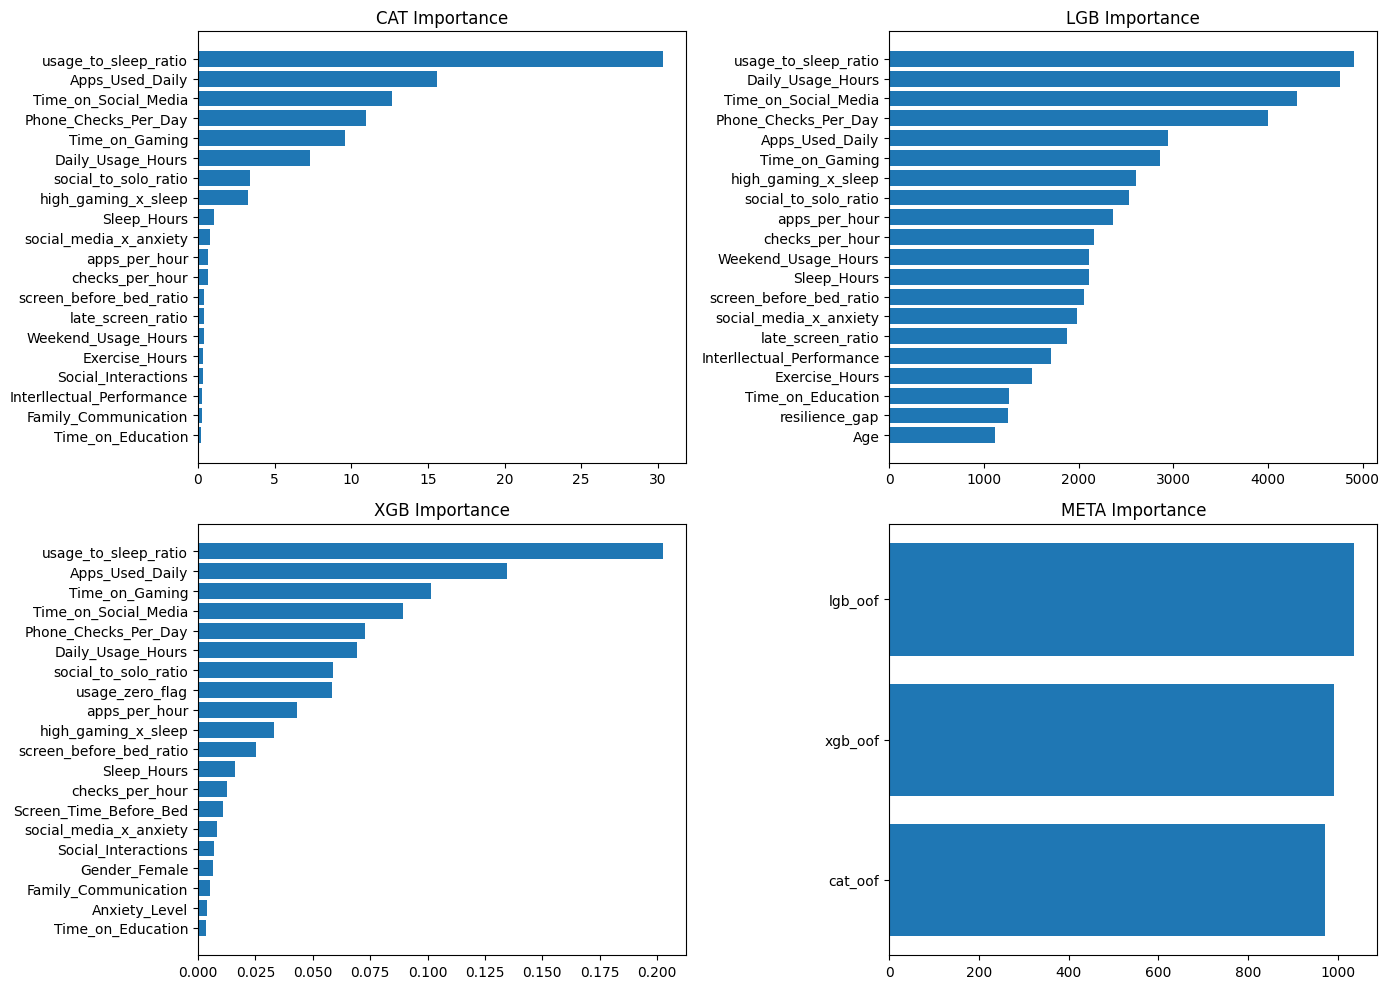

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, m in enumerate(best3):
    fi = pd.DataFrame({
        "feature": X_train.columns,
        "importance": fitted_models[m].feature_importances_
    }).sort_values("importance", ascending=False).head(20)

    axes[i].barh(fi["feature"], fi["importance"])
    axes[i].set_title(f"{m.upper()} Importance")
    axes[i].invert_yaxis()

meta_feats = [f"{m}_oof" for m in best3]
meta_fi = pd.DataFrame({
    "feature": meta_feats,
    "importance": fitted_models["stacked"].feature_importances_
}).sort_values("importance", ascending=False)

axes[len(best3)].barh(meta_fi["feature"], meta_fi["importance"])
axes[len(best3)].set_title("META Importance")
axes[len(best3)].invert_yaxis()

# --- Hide unused panels ---
for j in range(len(best3)+1, 4):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
top20_dict = {}

for m in best3:
    fi = pd.DataFrame({
        "feature": X_train.columns,
        "importance": fitted_models[m].feature_importances_
    }).sort_values("importance", ascending=False).head(20)

    top20_dict[m] = set(fi["feature"])

meta_feats = [f"{m}_oof" for m in best3]
meta_fi = pd.DataFrame({
    "feature": meta_feats,
    "importance": fitted_models["stacked"].feature_importances_
}).sort_values("importance", ascending=False)

top_meta = set(meta_fi["feature"])

unique_features = {
    m: top20_dict[m] - set().union(*(top20_dict[x] for x in best3 if x != m))
    for m in best3
}

shared_all = set.intersection(*(top20_dict[m] for m in best3))

union_all = set().union(*(top20_dict[m] for m in best3))

for m in best3:
    print(f"\nTop-20 features unique to {m.upper()}:")
    print(sorted(unique_features[m]))

print("\nShared across all base models:")
print(sorted(shared_all))

print("\nMETA importance ranking (stacked):")
print(meta_fi)

print("\nMeta model uses these OOF features:")
print(sorted(top_meta))



Top-20 features unique to CAT:
[]

Top-20 features unique to LGB:
['Age', 'resilience_gap']

Top-20 features unique to XGB:
['Anxiety_Level', 'Gender_Female', 'Screen_Time_Before_Bed', 'usage_zero_flag']

Shared across all base models:
['Apps_Used_Daily', 'Daily_Usage_Hours', 'Phone_Checks_Per_Day', 'Sleep_Hours', 'Time_on_Education', 'Time_on_Gaming', 'Time_on_Social_Media', 'apps_per_hour', 'checks_per_hour', 'high_gaming_x_sleep', 'screen_before_bed_ratio', 'social_media_x_anxiety', 'social_to_solo_ratio', 'usage_to_sleep_ratio']

META importance ranking (stacked):
   feature  importance
1  lgb_oof        1037
2  xgb_oof         992
0  cat_oof         971

Meta model uses these OOF features:
['cat_oof', 'lgb_oof', 'xgb_oof']


The differing feature-importance profiles across the base models show that each learner focuses on distinct structural patterns in the data, and this diversity is exactly what stacking is designed to exploit: by combining predictions that arise from different pattern-recognition behaviors, the meta-learner can integrate complementary signals and reduce reliance on any single model's biases. Even though stacking does not surpass the strongest individual model on test RMSE or R² in this case, the ensemble still provides value by blending these heterogeneous perspectives into a more stable predictor, and in settings where the underlying relationships are less clean or more fragmented, this same diversity often results in meaningful performance gains.

# CONCLUSION

Based on the model performance, the project successfully developed robust tools for predicting smartphone addiction, with Gradient Boosting models (especially CatBoost, achieving $R^2$ of 0.947 and RMSE of 0.362) demonstrating superior predictive power over traditional models, though all boosting methods showed significant overfitting to the training data.  While the Stacked Model did not substantially boost overall accuracy metrics ($R^2$ of 0.946), its lowest Test MAE (0.127) suggests it offers the most reliable and consistently close prediction of error magnitude in real-world scenarios. The comprehensive feature importance analysis identified usage timing and pattern features (e.g., usage_to_sleep_ratio, Apps_Used_Daily, Phone_Checks_Per_Day) as critical predictors, confirming that interventions should prioritize addressing specific, measurable digital behaviors and their interaction with sleep and social activity.